<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/Rules_vs_Logistic_Regression_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rules-based vs Logistic Regression classifier comparison

This standalone notebook compares the **local rules-based classifier** with the **local Logistic Regression classifier** produced by `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`.

It **does not retrain or alter either classifier**. It works from the classified GeoTIFFs already written to the classifier batch-output directory.

## Outputs

The analysis is performed **separately for Sentinel-2 and Sentinel-1** and exports:

- a paired-scene provenance manifest;
- per-scene overall agreement and Cohen's $\kappa$;
- pooled and per-scene Logistic Regression × rules agreement matrices;
- class-specific intersection-over-union (IoU) and Dice concordance;
- mapped class areas for each classifier on the **same common-valid pixels**;
- signed and absolute class-area differences;
- scene-level and monthly floating-plant area comparisons;
- georeferenced disagreement-transition GeoTIFFs for QGIS;
- dissertation-ready PNG figures and CSV tables;
- **accuracy** of the rules-based classifier against the labelled reference points
  (section 13), reported with the same metric suite the classifier notebook uses to
  score its candidate models, plus the same metrics for both classified maps sampled
  at those points;
- the **paired S2 fixed-validation comparison** (section 13h): the rules-based
  classifier and the expanded-data Logistic Regression model scored on the identical
  held-out points the classifier notebook set aside, which is the notebook's
  primary like-for-like threshold-versus-ML accuracy result.

> **Important:** in sections 4–12 neither classifier is treated as ground truth. Agreement, $\kappa$, IoU and Dice measure **concordance between methods**, not classification accuracy. Accuracy is reported separately in section 13, where both classifiers are scored against labelled reference points.

## 1. Mount Google Drive

In [1]:
from pathlib import Path

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
else:
    print("Not running in Colab; skipping Google Drive mount.")

Mounted at /content/drive


## 2. Imports

In [2]:
# Uncomment in a fresh environment if required:
# !pip -q install rasterio pandas numpy matplotlib pyproj scikit-learn

import hashlib
import json
import math
import re
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import Window
from pyproj import CRS, Geod, Transformer

# Section 13 scores the classifiers against labelled reference points with the
# same metrics the classifier notebook applies to its candidate models.
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

## 3. Configuration

The defaults match the current Winam classifier output structure and intentionally reject legacy export schemas.

Class coding is **sensor-dependent** and is copied from `S2_CLASS_NAMES` / `S1_CLASS_NAMES` in `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`. Sentinel-2 carries a fourth class (surface algae, code `3`); Sentinel-1 cannot separate surface algae from open water in SAR backscatter, so its mapping folds them into a single class and never writes code `3`. Both sensors code floating plants as `2` and NoData as `255`.

In [3]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
DRIVE_MYDRIVE = Path("/content/drive/MyDrive")

CLASSIFIER_ROOT = DRIVE_MYDRIVE / "Winam_RF_Training_Data"
CLASSIFIER_BATCH_DIR = CLASSIFIER_ROOT / "outputs" / "full_stack_batch"
CLASSIFIED_DIR = CLASSIFIER_BATCH_DIR / "classified_geotiffs"

OUTPUT_DIR = CLASSIFIER_ROOT / "outputs" / "rules_vs_logistic_regression"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
DISAGREEMENT_DIR = OUTPUT_DIR / "disagreement_geotiffs"

USE_LOCAL_STAGING = True
LOCAL_STAGE_DIR = Path("/content/rules_vs_lr_stage")

# ---------------------------------------------------------------------
# Scene / provenance filtering
# ---------------------------------------------------------------------
SENSOR_FILTER = ["S2", "S1"]

# Require current predictor schema tokens in filename prefixes.
REQUIRED_SCHEMA_TOKEN = {
    "S2": "s2_whlev_temporal_v1",
    "S1": "s1_scc_temporal_v1",
}

# Model output must be Logistic Regression.
MODEL_SLUG_REGEX = re.compile(r"logistic", re.IGNORECASE)

MODEL_SLUG_PREFERENCE = (
    "logistic_regression_baseline",
    "logistic_regression",
    "logistic",
)

START_DATE = None       # e.g. "2021-01-01"
END_DATE = None         # e.g. "2023-12-31"
MAX_SCENES_PER_SENSOR = None

# ---------------------------------------------------------------------
# Raster class coding
# ---------------------------------------------------------------------
NODATA_VALUE = 255

# Class coding is sensor-dependent. These maps are the S2_CLASS_NAMES and
# S1_CLASS_NAMES defined in Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb,
# and they apply to the Logistic Regression and rules-based rasters alike:
#
#   S2 keeps surface algae as its own class (code 3). Both the S2 training
#      labels ('A' -> 3) and the S2 rule branch NDMI >= 0.63 emit it, so an S2
#      raster legitimately contains four class codes.
#   S1 cannot separate surface algae from open water in SAR backscatter, so the
#      S1 training mapping folds 'A' into code 0 and no S1 raster contains a 3.
#
# Both sensors code floating plants as 2, so FLOATING_CLASS_CODE stays global.
SENSOR_CLASS_LABELS = {
    "S2": {
        0: "Open water",
        1: "LEV",
        2: "Floating plants",
        3: "Surface algae",
    },
    "S1": {
        0: "Open water / surface algae",
        1: "LEV",
        2: "Floating plants",
    },
}

FLOATING_CLASS_CODE = 2


def class_labels_for(sensor):
    """Return the {class code: label} map for one sensor."""
    try:
        return SENSOR_CLASS_LABELS[sensor]
    except KeyError:
        raise KeyError(
            f"No class coding is configured for sensor {sensor!r}. "
            f"Configured sensors: {sorted(SENSOR_CLASS_LABELS)}."
        ) from None


def class_codes_for(sensor):
    """Return the sorted tuple of valid class codes for one sensor."""
    return tuple(sorted(class_labels_for(sensor)))


# Fail during configuration rather than part-way through a long batch.
for _sensor in SENSOR_FILTER:
    _labels = class_labels_for(_sensor)

    if FLOATING_CLASS_CODE not in _labels:
        raise ValueError(
            f"{_sensor} class coding has no floating-plant code "
            f"{FLOATING_CLASS_CODE}: {_labels}."
        )

    if NODATA_VALUE in _labels:
        raise ValueError(
            f"{_sensor} class coding reuses NoData={NODATA_VALUE} as a class code."
        )

    # Disagreement transitions are written as 10*(LR+1)+(rules+1) into a uint8
    # band, so the largest class code has to stay inside that budget.
    _max_code = max(_labels)
    _max_transition = 10 * (_max_code + 1) + (_max_code + 1)
    if _max_transition >= NODATA_VALUE:
        raise ValueError(
            f"{_sensor} class code {_max_code} encodes disagreement transition "
            f"{_max_transition}, which collides with NoData={NODATA_VALUE}. "
            "Widen the transition encoding before adding further classes."
        )

# If a raster contains any non-NoData code outside its sensor's class codes the
# notebook stops immediately rather than silently dropping or relabelling it.
FAIL_ON_UNKNOWN_CLASS_CODE = True

# ---------------------------------------------------------------------
# Comparison behaviour
# ---------------------------------------------------------------------
STRICT_GRID_MATCH = True
READ_BLOCKSIZE = 2048

WRITE_DISAGREEMENT_RASTERS = True
OVERWRITE_OUTPUTS = False

N_TOP_DISAGREEMENT_QUICKLOOKS = 4

for p in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, DISAGREEMENT_DIR, LOCAL_STAGE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Classified raster directory:", CLASSIFIED_DIR)
print("Output directory:", OUTPUT_DIR)
for _sensor in SENSOR_FILTER:
    print(f"{_sensor} class mapping:", class_labels_for(_sensor))

Classified raster directory: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs
Output directory: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression
S2 class mapping: {0: 'Open water', 1: 'LEV', 2: 'Floating plants', 3: 'Surface algae'}
S1 class mapping: {0: 'Open water / surface algae', 1: 'LEV', 2: 'Floating plants'}


## 4. Discover and pair classifier outputs

The parser accepts the current schema-token filename forms as well as older forms, but `REQUIRED_SCHEMA_TOKEN` determines what is retained.

Sentinel-1 `_patch_cleaned.tif` model outputs are preferred over their raw equivalents. Google Drive collision copies such as `file (1).tif` are deprioritised.

In [4]:
_DATE_AT_END_RE = re.compile(
    r"(?P<start>\d{4}-\d{2}-\d{2})_to_(?P<end>\d{4}-\d{2}-\d{2})$"
)
_DRIVE_COLLISION_RE = re.compile(r"\s\((\d+)\)$")


def parse_scene_prefix(prefix):
    prefix = str(prefix)
    lower = prefix.lower()

    if lower.startswith("winam_s2"):
        sensor = "S2"
    elif lower.startswith("winam_s1"):
        sensor = "S1"
    else:
        return None

    m = _DATE_AT_END_RE.search(prefix)
    if not m:
        return None

    return {
        "prefix": prefix,
        "sensor": sensor,
        "start_date": m.group("start"),
        "end_date": m.group("end"),
    }


def strip_drive_collision(stem):
    return _DRIVE_COLLISION_RE.sub("", str(stem))


def parse_classifier_file(path):
    path = Path(path)
    if path.suffix.lower() not in {".tif", ".tiff"}:
        return None

    raw_stem = path.stem
    stem = strip_drive_collision(raw_stem)
    marker = "_local_"
    if marker not in stem:
        return None

    prefix, rest = stem.split(marker, 1)
    parsed = parse_scene_prefix(prefix)
    if parsed is None:
        return None

    if rest == "rules":
        role, model_slug, cleaned = "rule", "", False
    elif rest.endswith("_proba"):
        role, model_slug, cleaned = "proba", rest[:-len("_proba")], False
    elif rest.endswith("_patch_cleaned"):
        role, model_slug, cleaned = "model", rest[:-len("_patch_cleaned")], True
    else:
        role, model_slug, cleaned = "model", rest, False

    return {
        **parsed,
        "path": str(path),
        "role": role,
        "model_slug": model_slug,
        "patch_cleaned": bool(cleaned),
        "drive_collision_copy": bool(_DRIVE_COLLISION_RE.search(raw_stem)),
    }


def model_preference_score(rec):
    slug = str(rec["model_slug"]).lower()
    try:
        slug_rank = next(
            i for i, token in enumerate(MODEL_SLUG_PREFERENCE)
            if token.lower() in slug
        )
    except StopIteration:
        slug_rank = len(MODEL_SLUG_PREFERENCE)

    return (
        0 if rec["patch_cleaned"] else 1,
        slug_rank,
        1 if rec["drive_collision_copy"] else 0,
        rec["path"],
    )


def ordinary_file_score(rec):
    return (
        1 if rec["drive_collision_copy"] else 0,
        rec["path"],
    )


def discover_pairs(classified_dir):
    classified_dir = Path(classified_dir)
    if not classified_dir.exists():
        raise FileNotFoundError(
            f"Classifier output directory does not exist: {classified_dir}"
        )

    records = []
    for path in sorted(classified_dir.iterdir(), key=lambda p: p.name):
        if not path.is_file():
            continue
        rec = parse_classifier_file(path)
        if rec is not None:
            records.append(rec)

    raw = pd.DataFrame(records)
    if raw.empty:
        raise RuntimeError(
            f"No parseable classifier GeoTIFFs found in {classified_dir}"
        )

    rows = []
    for prefix, grp in raw.groupby("prefix", sort=True):
        sensor = grp["sensor"].iloc[0]

        model_recs = [
            row._asdict() for row in grp.itertuples(index=False)
            if row.role == "model" and MODEL_SLUG_REGEX.search(str(row.model_slug))
        ]
        rule_recs = [
            row._asdict() for row in grp.itertuples(index=False)
            if row.role == "rule"
        ]

        chosen_model = sorted(model_recs, key=model_preference_score)[0] if model_recs else None
        chosen_rule = sorted(rule_recs, key=ordinary_file_score)[0] if rule_recs else None

        if chosen_model is None and chosen_rule is None:
            status = "missing_model_and_rule"
        elif chosen_model is None:
            status = "missing_logistic_model"
        elif chosen_rule is None:
            status = "missing_rule"
        else:
            status = "paired"

        required_token = REQUIRED_SCHEMA_TOKEN.get(sensor)
        schema_ok = required_token is None or required_token in prefix

        rows.append({
            "sensor": sensor,
            "start_date": grp["start_date"].iloc[0],
            "end_date": grp["end_date"].iloc[0],
            "prefix": prefix,
            "schema_token_required": required_token,
            "schema_ok": bool(schema_ok),
            "status": status,
            "model_slug": "" if chosen_model is None else chosen_model["model_slug"],
            "model_patch_cleaned": False if chosen_model is None else chosen_model["patch_cleaned"],
            "model_tif": "" if chosen_model is None else chosen_model["path"],
            "rule_tif": "" if chosen_rule is None else chosen_rule["path"],
            "n_logistic_candidates": len(model_recs),
            "n_rule_candidates": len(rule_recs),
        })

    manifest = pd.DataFrame(rows)
    manifest["start_date"] = pd.to_datetime(manifest["start_date"])
    manifest["end_date"] = pd.to_datetime(manifest["end_date"])
    return manifest.sort_values(
        ["sensor", "start_date", "end_date", "prefix"]
    ).reset_index(drop=True)


all_manifest = discover_pairs(CLASSIFIED_DIR)
all_manifest.to_csv(TABLE_DIR / "rules_vs_lr_discovery_audit.csv", index=False)

paired = all_manifest[
    all_manifest["sensor"].isin(SENSOR_FILTER)
    & all_manifest["schema_ok"]
    & all_manifest["status"].eq("paired")
].copy()

if START_DATE is not None:
    paired = paired[paired["end_date"] >= pd.Timestamp(START_DATE)]
if END_DATE is not None:
    paired = paired[paired["start_date"] <= pd.Timestamp(END_DATE)]

if MAX_SCENES_PER_SENSOR is not None:
    paired = (
        paired.sort_values(["sensor", "start_date"])
        .groupby("sensor", group_keys=False)
        .head(int(MAX_SCENES_PER_SENSOR))
    )

paired = paired.reset_index(drop=True)
paired.to_csv(TABLE_DIR / "rules_vs_lr_paired_manifest.csv", index=False)

print("Discovery status:")
display(
    all_manifest.groupby(["sensor", "schema_ok", "status"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)

print("\nPaired scenes retained:")
display(
    paired.groupby("sensor")
    .agg(
        scenes=("prefix", "size"),
        first_date=("start_date", "min"),
        last_date=("end_date", "max"),
    )
    .reset_index()
)

if paired.empty:
    raise RuntimeError(
        "No paired current-schema Logistic Regression/rules rasters were retained. "
        "Inspect rules_vs_lr_discovery_audit.csv and the configuration above."
    )

Discovery status:


,sensor,schema_ok,status,n
0,S1,False,paired,540
1,S2,False,paired,730
2,S2,True,paired,372



Paired scenes retained:


,sensor,scenes,first_date,last_date
0,S2,372,2017-04-02,2026-07-15


## 5. Raster integrity and metric helpers

All concordance metrics are computed only where **both rasters** contain a recognised, non-NoData class.

The notebook also records valid-mask overlap, so a coverage mismatch cannot be mistaken for classification disagreement.

In [5]:
def iter_fixed_windows(width, height, blocksize=READ_BLOCKSIZE):
    for row_off in range(0, height, blocksize):
        h = min(blocksize, height - row_off)
        for col_off in range(0, width, blocksize):
            w = min(blocksize, width - col_off)
            yield Window(col_off=col_off, row_off=row_off, width=w, height=h)


def assert_same_grid(a, b):
    problems = []
    if (a.width, a.height) != (b.width, b.height):
        problems.append(f"shape {(a.height, a.width)} != {(b.height, b.width)}")
    if a.crs != b.crs:
        problems.append(f"CRS {a.crs} != {b.crs}")
    if not a.transform.almost_equals(b.transform):
        problems.append(f"transform {a.transform} != {b.transform}")

    if problems:
        msg = "Raster grids do not match: " + "; ".join(problems)
        if STRICT_GRID_MATCH:
            raise ValueError(msg)
        warnings.warn(msg)


def staged_copy(path):
    path = Path(path)
    if not USE_LOCAL_STAGING:
        return path

    digest = hashlib.sha1(str(path).encode("utf-8")).hexdigest()[:12]
    local = LOCAL_STAGE_DIR / f"{digest}_{path.name}"

    if not local.exists() or local.stat().st_size != path.stat().st_size:
        shutil.copy2(path, local)

    return local


def class_valid(arr, sensor):
    return np.isin(arr, class_codes_for(sensor))


def check_unknown_codes(arr, valid_nodata_mask, source_name, sensor):
    class_codes = class_codes_for(sensor)
    observed = np.unique(arr[valid_nodata_mask])
    unknown = [int(x) for x in observed if int(x) not in class_codes]
    if unknown:
        message = (
            f"{source_name} contains unexpected non-NoData class codes: {unknown}. "
            f"Expected only {class_codes} plus NoData={NODATA_VALUE} for {sensor}."
        )
        if FAIL_ON_UNKNOWN_CLASS_CODE:
            raise ValueError(message)
        warnings.warn(message)
    return unknown


def cohen_kappa_from_matrix(matrix):
    matrix = np.asarray(matrix, dtype=np.float64)
    n = matrix.sum()
    if n == 0:
        return np.nan

    po = np.trace(matrix) / n
    pe = np.sum(matrix.sum(axis=1) * matrix.sum(axis=0)) / (n * n)

    if np.isclose(1.0 - pe, 0.0):
        return np.nan

    return float((po - pe) / (1.0 - pe))


_GEOD = Geod(ellps="WGS84")


def projected_pixel_area_ha(src):
    crs = CRS.from_user_input(src.crs)
    if not crs.is_projected:
        return None

    unit_factor = crs.axis_info[0].unit_conversion_factor if crs.axis_info else 1.0
    area_native = abs(
        src.transform.a * src.transform.e
        - src.transform.b * src.transform.d
    )
    return float(area_native * (unit_factor ** 2) / 10000.0)


def geographic_row_pixel_areas_ha(src, row_start, nrows):
    if not np.isclose(src.transform.b, 0.0) or not np.isclose(src.transform.d, 0.0):
        raise ValueError(
            "Geographic raster has rotation/shear; geodesic pixel area is "
            "not implemented for this transform."
        )

    areas = np.empty(nrows, dtype=np.float64)
    col = 0

    for i, row in enumerate(range(row_start, row_start + nrows)):
        lon0, lat0 = src.transform * (col, row)
        lon1, lat1 = src.transform * (col + 1, row + 1)

        lons = [lon0, lon1, lon1, lon0]
        lats = [lat0, lat0, lat1, lat1]

        area_m2, _ = _GEOD.polygon_area_perimeter(lons, lats)
        areas[i] = abs(area_m2) / 10000.0

    return areas


def row_pixel_areas_ha(src, row_start, nrows):
    constant = projected_pixel_area_ha(src)
    if constant is not None:
        return np.full(nrows, constant, dtype=np.float64)

    crs = CRS.from_user_input(src.crs)
    if crs.is_geographic:
        return geographic_row_pixel_areas_ha(src, row_start, nrows)

    raise ValueError(f"Unsupported CRS for area calculation: {src.crs}")


def matrix_long_form(matrix, sensor, prefix):
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    rows = []
    for i, lr_code in enumerate(class_codes):
        row_total = matrix[i].sum()
        for j, rule_code in enumerate(class_codes):
            count = int(matrix[i, j])
            rows.append({
                "sensor": sensor,
                "prefix": prefix,
                "lr_code": lr_code,
                "lr_class": class_labels[lr_code],
                "rule_code": rule_code,
                "rule_class": class_labels[rule_code],
                "pixels": count,
                "row_percent": (100.0 * count / row_total) if row_total else np.nan,
            })
    return rows

## 6. Compare one paired scene

The disagreement raster uses:

- `0` = classifiers agree;
- `10 × (LR code + 1) + (rule code + 1)` = a disagreement transition;
- `255` = not common-valid.

This preserves disagreement direction for QGIS mapping.

In [6]:
def compare_scene(row):
    sensor = row["sensor"]
    prefix = row["prefix"]

    # Class coding differs between S2 (four classes) and S1 (three), so every
    # matrix, area accumulator and label lookup below is sized for this sensor.
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    model_path = Path(row["model_tif"])
    rule_path = Path(row["rule_tif"])

    local_model = staged_copy(model_path)
    local_rule = staged_copy(rule_path)

    transition_drive = DISAGREEMENT_DIR / f"{prefix}_lr_vs_rules_disagreement.tif"
    transition_local = (
        LOCAL_STAGE_DIR / transition_drive.name
        if USE_LOCAL_STAGING else transition_drive
    )

    matrix = np.zeros((len(class_codes), len(class_codes)), dtype=np.int64)

    model_valid_pixels = 0
    rule_valid_pixels = 0
    common_valid_pixels = 0
    valid_union_pixels = 0
    disagreement_pixels = 0
    common_valid_area_ha = 0.0

    lr_area_ha = {c: 0.0 for c in class_codes}
    rule_area_ha = {c: 0.0 for c in class_codes}
    intersection_area_ha = {c: 0.0 for c in class_codes}
    union_area_ha = {c: 0.0 for c in class_codes}

    with rasterio.open(local_model) as lr_src, rasterio.open(local_rule) as rule_src:
        assert_same_grid(lr_src, rule_src)

        out_profile = lr_src.profile.copy()
        out_profile.update(
            count=1,
            dtype="uint8",
            nodata=NODATA_VALUE,
            compress="deflate",
        )

        write_transition = (
            WRITE_DISAGREEMENT_RASTERS
            and (OVERWRITE_OUTPUTS or not transition_drive.exists())
        )

        dst = rasterio.open(transition_local, "w", **out_profile) if write_transition else None

        try:
            for window in iter_fixed_windows(lr_src.width, lr_src.height):
                lr = lr_src.read(1, window=window)
                rules = rule_src.read(1, window=window)

                lr_non_nodata = lr != NODATA_VALUE
                rule_non_nodata = rules != NODATA_VALUE

                check_unknown_codes(lr, lr_non_nodata, f"{prefix} LR", sensor)
                check_unknown_codes(rules, rule_non_nodata, f"{prefix} rules", sensor)

                lr_valid = lr_non_nodata & class_valid(lr, sensor)
                rule_valid = rule_non_nodata & class_valid(rules, sensor)
                common = lr_valid & rule_valid
                union_valid = lr_valid | rule_valid

                model_valid_pixels += int(lr_valid.sum())
                rule_valid_pixels += int(rule_valid.sum())
                common_valid_pixels += int(common.sum())
                valid_union_pixels += int(union_valid.sum())

                if common.any():
                    for i, lr_code in enumerate(class_codes):
                        lr_mask = common & (lr == lr_code)
                        for j, rule_code in enumerate(class_codes):
                            matrix[i, j] += int(
                                np.count_nonzero(lr_mask & (rules == rule_code))
                            )

                    disagreement_pixels += int(np.count_nonzero(common & (lr != rules)))

                    row_areas = row_pixel_areas_ha(
                        lr_src,
                        int(window.row_off),
                        int(window.height),
                    )

                    for rr in range(int(window.height)):
                        common_row = common[rr]
                        if not common_row.any():
                            continue

                        pixel_area = row_areas[rr]
                        common_valid_area_ha += float(
                            np.count_nonzero(common_row) * pixel_area
                        )

                        lr_row = lr[rr]
                        rule_row = rules[rr]

                        for c in class_codes:
                            a = common_row & (lr_row == c)
                            b = common_row & (rule_row == c)
                            inter = a & b
                            union = a | b

                            lr_area_ha[c] += float(np.count_nonzero(a) * pixel_area)
                            rule_area_ha[c] += float(np.count_nonzero(b) * pixel_area)
                            intersection_area_ha[c] += float(
                                np.count_nonzero(inter) * pixel_area
                            )
                            union_area_ha[c] += float(
                                np.count_nonzero(union) * pixel_area
                            )

                if dst is not None:
                    transition = np.full(lr.shape, NODATA_VALUE, dtype=np.uint8)

                    agree = common & (lr == rules)
                    disagree = common & (lr != rules)

                    transition[agree] = 0

                    if disagree.any():
                        transition[disagree] = (
                            10 * (lr[disagree].astype(np.uint8) + 1)
                            + (rules[disagree].astype(np.uint8) + 1)
                        )

                    dst.write(transition, 1, window=window)

            if dst is not None:
                dst.update_tags(
                    comparison="Logistic Regression vs rules-based classifier",
                    zero="agreement",
                    nodata=str(NODATA_VALUE),
                    transition_code="10*(LR_class_code+1)+(rules_class_code+1)",
                )

        finally:
            if dst is not None:
                dst.close()

    if write_transition and USE_LOCAL_STAGING:
        shutil.copy2(transition_local, transition_drive)

    total = int(matrix.sum())

    agreement = float(np.trace(matrix) / total) if total else np.nan
    kappa = cohen_kappa_from_matrix(matrix)

    disagreement_fraction = (
        disagreement_pixels / common_valid_pixels
        if common_valid_pixels else np.nan
    )

    valid_mask_jaccard = (
        common_valid_pixels / valid_union_pixels
        if valid_union_pixels else np.nan
    )

    summary = {
        "sensor": sensor,
        "start_date": row["start_date"],
        "end_date": row["end_date"],
        "prefix": prefix,
        "model_slug": row["model_slug"],
        "model_patch_cleaned": bool(row["model_patch_cleaned"]),
        "model_tif": str(model_path),
        "rule_tif": str(rule_path),
        "common_valid_pixels": common_valid_pixels,
        "model_valid_pixels": model_valid_pixels,
        "rule_valid_pixels": rule_valid_pixels,
        "valid_mask_jaccard": valid_mask_jaccard,
        "common_valid_area_ha": common_valid_area_ha,
        "overall_agreement": agreement,
        "disagreement_fraction": disagreement_fraction,
        "cohen_kappa": kappa,
        "disagreement_tif": str(transition_drive) if WRITE_DISAGREEMENT_RASTERS else "",
    }

    class_rows = []

    for i, c in enumerate(class_codes):
        lr_count = int(matrix[i, :].sum())
        rule_count = int(matrix[:, i].sum())
        intersection_count = int(matrix[i, i])
        union_count = lr_count + rule_count - intersection_count

        iou = intersection_count / union_count if union_count else np.nan
        dice = (
            2 * intersection_count / (lr_count + rule_count)
            if (lr_count + rule_count) else np.nan
        )

        lr_area = lr_area_ha[c]
        rule_area = rule_area_ha[c]
        diff = lr_area - rule_area

        class_rows.append({
            "sensor": sensor,
            "start_date": row["start_date"],
            "end_date": row["end_date"],
            "prefix": prefix,
            "class_code": c,
            "class_name": class_labels[c],
            "lr_pixels": lr_count,
            "rule_pixels": rule_count,
            "intersection_pixels": intersection_count,
            "union_pixels": union_count,
            "iou": iou,
            "dice": dice,
            "lr_area_ha": lr_area,
            "rule_area_ha": rule_area,
            "area_difference_lr_minus_rules_ha": diff,
            "absolute_area_difference_ha": abs(diff),
            "relative_area_difference_vs_lr": diff / lr_area if lr_area else np.nan,
            "intersection_area_ha": intersection_area_ha[c],
            "union_area_ha": union_area_ha[c],
        })

    floating_row = next(
        x for x in class_rows
        if x["class_code"] == FLOATING_CLASS_CODE
    )

    summary["floating_lr_area_ha"] = floating_row["lr_area_ha"]
    summary["floating_rule_area_ha"] = floating_row["rule_area_ha"]
    summary["floating_area_difference_lr_minus_rules_ha"] = floating_row[
        "area_difference_lr_minus_rules_ha"
    ]
    summary["floating_absolute_area_difference_ha"] = floating_row[
        "absolute_area_difference_ha"
    ]
    summary["floating_iou"] = floating_row["iou"]
    summary["floating_dice"] = floating_row["dice"]

    summary["floating_lr_cover_fraction"] = (
        floating_row["lr_area_ha"] / common_valid_area_ha
        if common_valid_area_ha else np.nan
    )
    summary["floating_rule_cover_fraction"] = (
        floating_row["rule_area_ha"] / common_valid_area_ha
        if common_valid_area_ha else np.nan
    )

    matrix_rows = matrix_long_form(
        matrix,
        sensor=sensor,
        prefix=prefix,
    )

    return summary, class_rows, matrix_rows, matrix

## 7. Run all paired comparisons

This is the only potentially long-running section. Each pair is staged and read window-by-window, so memory use remains bounded.

In [7]:
scene_summaries = []
class_comparisons = []
matrix_rows_all = []
scene_matrices = {}

for idx, row in paired.iterrows():
    print(
        f"[{idx + 1}/{len(paired)}] "
        f"{row['sensor']} {row['start_date'].date()} — {row['prefix']}"
    )

    summary, class_rows, matrix_rows, matrix = compare_scene(row)

    scene_summaries.append(summary)
    class_comparisons.extend(class_rows)
    matrix_rows_all.extend(matrix_rows)
    scene_matrices[(row["sensor"], row["prefix"])] = matrix

scene_df = pd.DataFrame(scene_summaries).sort_values(
    ["sensor", "start_date", "end_date"]
).reset_index(drop=True)

class_df = pd.DataFrame(class_comparisons).sort_values(
    ["sensor", "start_date", "class_code"]
).reset_index(drop=True)

matrix_long_df = pd.DataFrame(matrix_rows_all).sort_values(
    ["sensor", "prefix", "lr_code", "rule_code"]
).reset_index(drop=True)

scene_df.to_csv(
    TABLE_DIR / "rules_vs_lr_scene_summary.csv",
    index=False,
)
class_df.to_csv(
    TABLE_DIR / "rules_vs_lr_class_comparison_by_scene.csv",
    index=False,
)
matrix_long_df.to_csv(
    TABLE_DIR / "rules_vs_lr_agreement_matrix_by_scene.csv",
    index=False,
)

print("Scene-level comparison complete.")
display(scene_df.head())

[1/372] S2 2017-04-02 — winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03
[2/372] S2 2017-05-22 — winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23
[3/372] S2 2017-06-11 — winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12
[4/372] S2 2017-10-04 — winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05
[5/372] S2 2018-05-12 — winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13
[6/372] S2 2018-12-23 — winam_s2_predictors_s2_whlev_temporal_v1_2018-12-23_to_2018-12-24
[7/372] S2 2018-12-28 — winam_s2_predictors_s2_whlev_temporal_v1_2018-12-28_to_2018-12-29
[8/372] S2 2019-01-02 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-02_to_2019-01-03
[9/372] S2 2019-01-07 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-07_to_2019-01-08
[10/372] S2 2019-01-12 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-12_to_2019-01-13
[11/372] S2 2019-01-17 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-17_to_2019-01-18
[12/372]

,sensor,start_date,end_date,prefix,model_slug,model_patch_cleaned,model_tif,rule_tif,common_valid_pixels,model_valid_pixels,rule_valid_pixels,valid_mask_jaccard,common_valid_area_ha,overall_agreement,disagreement_fraction,cohen_kappa,disagreement_tif,floating_lr_area_ha,floating_rule_area_ha,floating_area_difference_lr_minus_rules_ha,floating_absolute_area_difference_ha,floating_iou,floating_dice,floating_lr_cover_fraction,floating_rule_cover_fraction
0,S2,2017-04-02,2017-04-03,winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03...,548595,548595,548595,1.0,5485.95,0.796385,0.203615,0.618342,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02...,443.39,1532.83,-1089.44,1089.44,0.287331,0.446398,0.080823,0.279410
1,S2,2017-05-22,2017-05-23,winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23...,278828,278828,278828,1.0,2788.28,0.797807,0.202193,0.625683,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22...,198.60,704.78,-506.18,506.18,0.249730,0.399655,0.071227,0.252765
2,S2,2017-06-11,2017-06-12,winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12...,13736733,13736733,13736733,1.0,137367.33,0.935306,0.064694,0.421101,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11...,1611.27,2714.26,-1102.99,1102.99,0.474227,0.643357,0.011730,0.019759
3,S2,2017-10-04,2017-10-05,winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05...,548595,548595,548595,1.0,5485.95,0.852722,0.147278,0.629957,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04...,0.87,318.42,-317.55,317.55,0.002386,0.004761,0.000159,0.058043
4,S2,2018-05-12,2018-05-13,winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13...,547254,547254,547254,1.0,5472.54,0.937179,0.062821,0.780909,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagree

## 8. Pooled sensor-level summaries

Pooled matrices sum all common-valid pixels across paired scenes for each sensor. A separate sensor summary also reports scene-level means and medians.

In [8]:
pooled_matrix_rows = []
sensor_summary_rows = []
pooled_matrices = {}

for sensor in SENSOR_FILTER:
    sensor_keys = [
        key for key in scene_matrices
        if key[0] == sensor
    ]

    if not sensor_keys:
        continue

    pooled = np.sum(
        [scene_matrices[key] for key in sensor_keys],
        axis=0,
    )
    pooled_matrices[sensor] = pooled

    pooled_total = pooled.sum()
    pooled_agreement = (
        np.trace(pooled) / pooled_total
        if pooled_total else np.nan
    )
    pooled_kappa = cohen_kappa_from_matrix(pooled)

    pooled_matrix_rows.extend(
        matrix_long_form(
            pooled,
            sensor=sensor,
            prefix="POOLED",
        )
    )

    ss = scene_df[scene_df["sensor"] == sensor]

    sensor_summary_rows.append({
        "sensor": sensor,
        "paired_scenes": len(ss),
        "first_date": ss["start_date"].min(),
        "last_date": ss["end_date"].max(),
        "pooled_common_valid_pixels": int(pooled_total),
        "pooled_overall_agreement": pooled_agreement,
        "pooled_cohen_kappa": pooled_kappa,
        "mean_scene_agreement": ss["overall_agreement"].mean(),
        "median_scene_agreement": ss["overall_agreement"].median(),
        "mean_scene_kappa": ss["cohen_kappa"].mean(),
        "median_scene_kappa": ss["cohen_kappa"].median(),
        "mean_valid_mask_jaccard": ss["valid_mask_jaccard"].mean(),
        "mean_floating_lr_area_ha": ss["floating_lr_area_ha"].mean(),
        "mean_floating_rule_area_ha": ss["floating_rule_area_ha"].mean(),
        "mean_floating_area_difference_lr_minus_rules_ha": (
            ss["floating_area_difference_lr_minus_rules_ha"].mean()
        ),
        "mean_absolute_floating_area_difference_ha": (
            ss["floating_absolute_area_difference_ha"].mean()
        ),
        "mean_floating_iou": ss["floating_iou"].mean(),
        "mean_floating_dice": ss["floating_dice"].mean(),
    })

pooled_matrix_df = pd.DataFrame(pooled_matrix_rows)
sensor_summary_df = pd.DataFrame(sensor_summary_rows)

pooled_matrix_df.to_csv(
    TABLE_DIR / "rules_vs_lr_pooled_agreement_matrix.csv",
    index=False,
)
sensor_summary_df.to_csv(
    TABLE_DIR / "rules_vs_lr_sensor_summary.csv",
    index=False,
)

display(sensor_summary_df)

,sensor,paired_scenes,first_date,last_date,pooled_common_valid_pixels,pooled_overall_agreement,pooled_cohen_kappa,mean_scene_agreement,median_scene_agreement,mean_scene_kappa,median_scene_kappa,mean_valid_mask_jaccard,mean_floating_lr_area_ha,mean_floating_rule_area_ha,mean_floating_area_difference_lr_minus_rules_ha,mean_absolute_floating_area_difference_ha,mean_floating_iou,mean_floating_dice
0,S2,372,2017-04-02,2026-07-15,4807567506,0.942128,0.374489,0.940057,0.957501,0.412201,0.410668,1.0,909.854624,1176.35957,-266.504946,329.915376,0.497917,0.625101


## 9. Monthly floating-plant comparison

If several classified scenes fall in the same calendar month, the notebook takes the **mean of scene-level mapped areas and cover fractions**. It does not sum repeated acquisitions within a month.

In [9]:
scene_df["month"] = (
    scene_df["start_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_df = (
    scene_df.groupby(["sensor", "month"], as_index=False)
    .agg(
        scenes=("prefix", "size"),
        floating_lr_area_ha=("floating_lr_area_ha", "mean"),
        floating_rule_area_ha=("floating_rule_area_ha", "mean"),
        floating_area_difference_lr_minus_rules_ha=(
            "floating_area_difference_lr_minus_rules_ha",
            "mean",
        ),
        floating_absolute_area_difference_ha=(
            "floating_absolute_area_difference_ha",
            "mean",
        ),
        floating_lr_cover_fraction=(
            "floating_lr_cover_fraction",
            "mean",
        ),
        floating_rule_cover_fraction=(
            "floating_rule_cover_fraction",
            "mean",
        ),
        overall_agreement=("overall_agreement", "mean"),
        cohen_kappa=("cohen_kappa", "mean"),
        floating_iou=("floating_iou", "mean"),
        common_valid_area_ha=("common_valid_area_ha", "mean"),
    )
)

monthly_df.to_csv(
    TABLE_DIR / "rules_vs_lr_monthly_comparison.csv",
    index=False,
)
display(monthly_df.head())

,sensor,month,scenes,floating_lr_area_ha,floating_rule_area_ha,floating_area_difference_lr_minus_rules_ha,floating_absolute_area_difference_ha,floating_lr_cover_fraction,floating_rule_cover_fraction,overall_agreement,cohen_kappa,floating_iou,common_valid_area_ha
0,S2,2017-04-01,1,443.39,1532.83,-1089.44,1089.44,0.080823,0.279410,0.796385,0.618342,0.287331,5485.95
1,S2,2017-05-01,1,198.60,704.78,-506.18,506.18,0.071227,0.252765,0.797807,0.625683,0.249730,2788.28
2,S2,2017-06-01,1,1611.27,2714.26,-1102.99,1102.99,0.011730,0.019759,0.935306,0.421101,0.474227,137367.33
3,S2,2017-10-01,1,0.87,318.42,-317.55,317.55,0.000159,0.058043,0.852722,0.629957,0.002386,5485.95
4,S2,2018-05-01,1,216.18,545.59,-329.41,329.41,0.039503,0.099696,0.937179,0.780909,0.391539,5472.54


## 10. Dissertation-ready figures

Figures are produced separately for S2 and S1.

### A. Pooled agreement matrix

Rows are Logistic Regression classes; columns are rules-based classes. Cell text gives the pixel count and the percentage of that Logistic Regression row.

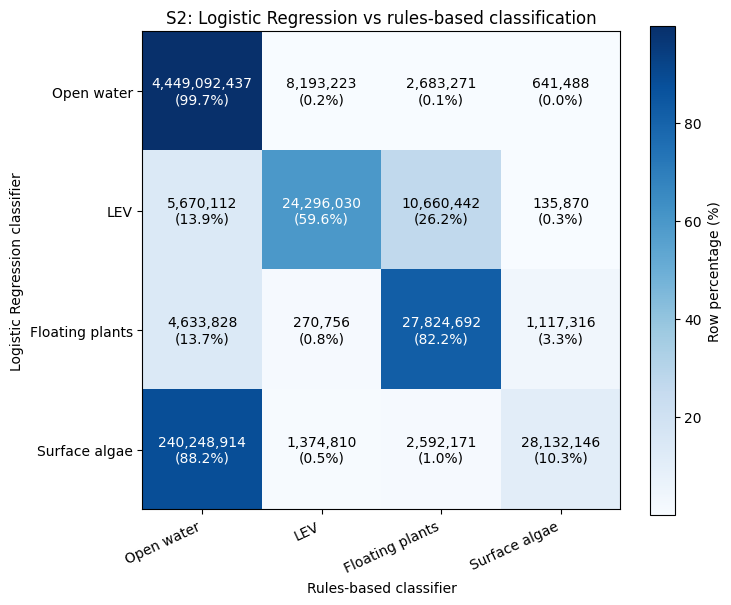

In [10]:
def plot_pooled_matrix(sensor, matrix):
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    row_totals = matrix.sum(axis=1, keepdims=True)

    row_pct = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype=float),
        where=row_totals != 0,
    ) * 100.0

    fig, ax = plt.subplots(figsize=(7.6, 6.2))
    im = ax.imshow(row_pct, cmap="Blues")

    labels = [class_labels[c] for c in class_codes]

    ax.set_xticks(
        range(len(labels)),
        labels=labels,
        rotation=25,
        ha="right",
    )
    ax.set_yticks(
        range(len(labels)),
        labels=labels,
    )

    ax.set_xlabel("Rules-based classifier")
    ax.set_ylabel("Logistic Regression classifier")
    ax.set_title(
        f"{sensor}: Logistic Regression vs rules-based classification"
    )

    for i in range(len(class_codes)):
        for j in range(len(class_codes)):
            # Optional: adjust text color based on background intensity for readability
            text_color = "white" if row_pct[i, j] > 50 else "black"
            ax.text(
                j,
                i,
                f"{int(matrix[i, j]):,}\n({row_pct[i, j]:.1f}%)",
                ha="center",
                va="center",
                color=text_color
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row percentage (%)")

    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_pooled_agreement_matrix.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor, matrix in pooled_matrices.items():
    plot_pooled_matrix(sensor, matrix)


### B. Floating-plant mapped area through time

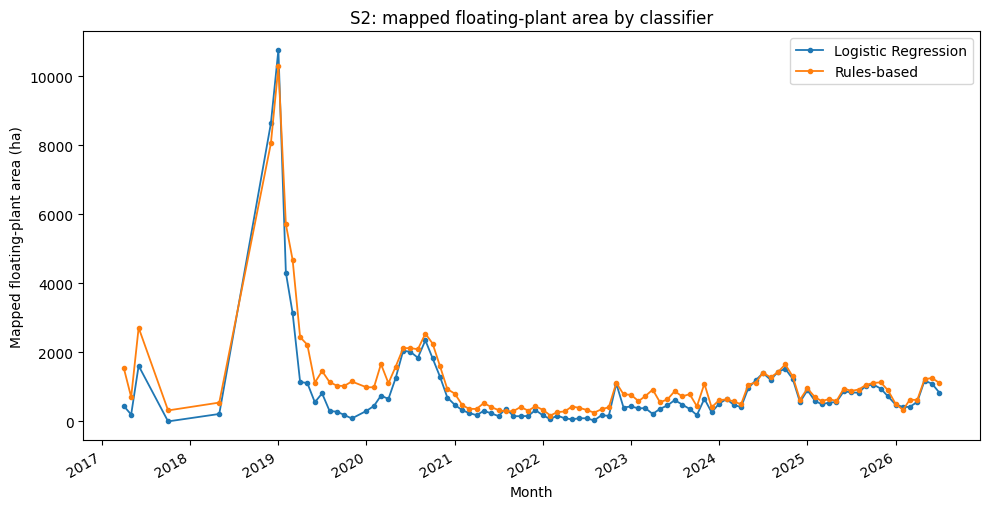

In [11]:
def plot_floating_area_time_series(sensor):
    d = monthly_df[
        monthly_df["sensor"] == sensor
    ].sort_values("month")

    if d.empty:
        return None

    fig, ax = plt.subplots(figsize=(10.0, 5.2))

    ax.plot(
        d["month"],
        d["floating_lr_area_ha"],
        marker="o",
        markersize=3,
        linewidth=1.3,
        label="Logistic Regression",
    )

    ax.plot(
        d["month"],
        d["floating_rule_area_ha"],
        marker="o",
        markersize=3,
        linewidth=1.3,
        label="Rules-based",
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Mapped floating-plant area (ha)")
    ax.set_title(
        f"{sensor}: mapped floating-plant area by classifier"
    )
    ax.legend()

    fig.autofmt_xdate()
    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_floating_area_timeseries.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    plot_floating_area_time_series(sensor)

### C. Difference in mapped floating-plant area

Positive values indicate that Logistic Regression mapped **more** floating-plant area than the rules-based classifier.

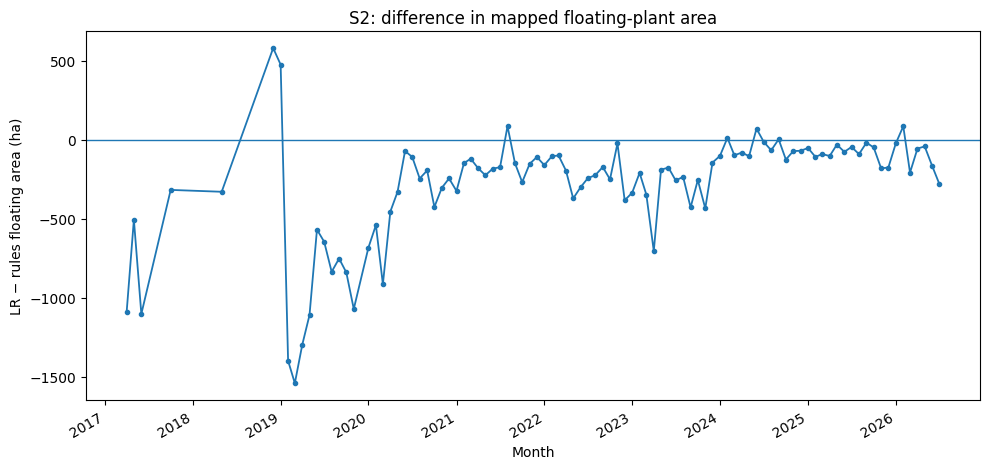

In [12]:
def plot_floating_area_difference(sensor):
    d = monthly_df[
        monthly_df["sensor"] == sensor
    ].sort_values("month")

    if d.empty:
        return None

    fig, ax = plt.subplots(figsize=(10.0, 4.8))

    ax.axhline(0, linewidth=1)
    ax.plot(
        d["month"],
        d["floating_area_difference_lr_minus_rules_ha"],
        marker="o",
        markersize=3,
        linewidth=1.3,
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("LR − rules floating area (ha)")
    ax.set_title(
        f"{sensor}: difference in mapped floating-plant area"
    )

    fig.autofmt_xdate()
    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_floating_area_difference.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    plot_floating_area_difference(sensor)

### D. Scene-level agreement through time

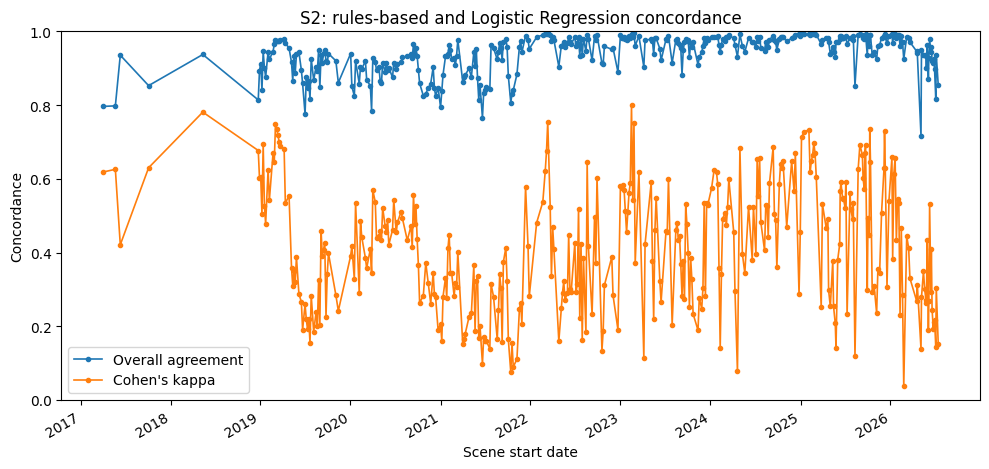

In [13]:
def plot_scene_agreement(sensor):
    d = scene_df[
        scene_df["sensor"] == sensor
    ].sort_values("start_date")

    if d.empty:
        return None

    fig, ax = plt.subplots(figsize=(10.0, 4.8))

    ax.plot(
        d["start_date"],
        d["overall_agreement"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Overall agreement",
    )

    ax.plot(
        d["start_date"],
        d["cohen_kappa"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Cohen's kappa",
    )

    ax.set_xlabel("Scene start date")
    ax.set_ylabel("Concordance")
    ax.set_ylim(0, 1)
    ax.set_title(
        f"{sensor}: rules-based and Logistic Regression concordance"
    )
    ax.legend()

    fig.autofmt_xdate()
    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_agreement_timeseries.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    plot_scene_agreement(sensor)

### E. Spatial disagreement quicklooks

For each sensor, the notebook renders the scenes with the highest disagreement fraction. The GeoTIFF itself remains the authoritative spatial output for QGIS.

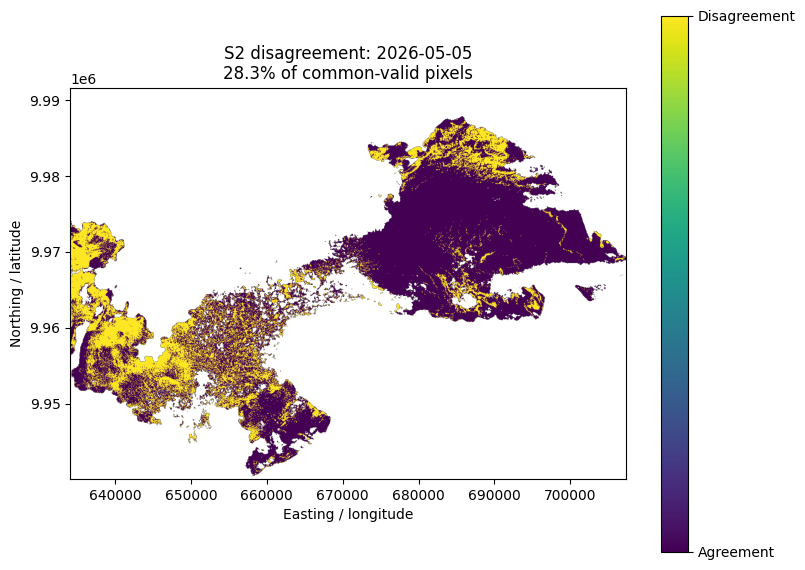

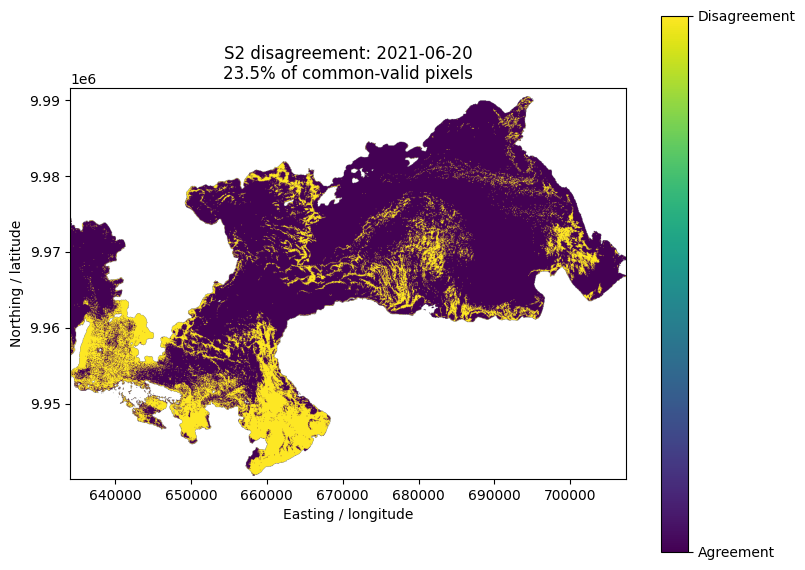

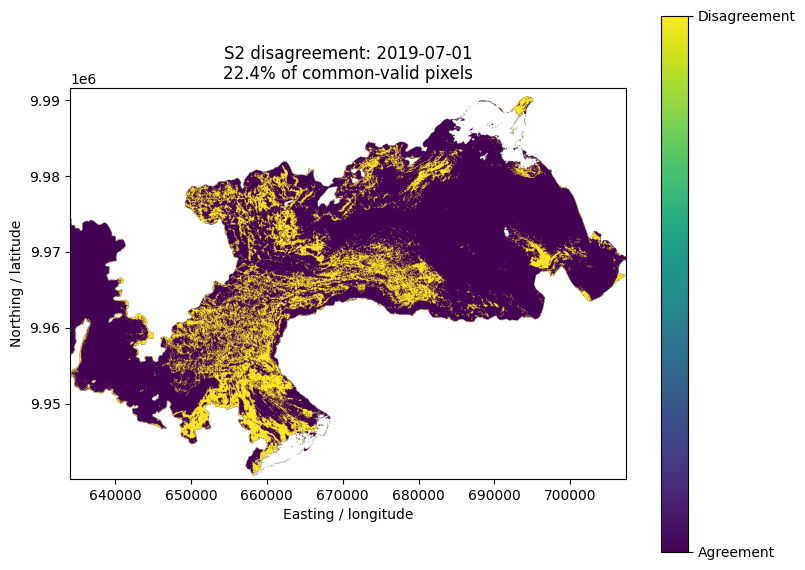

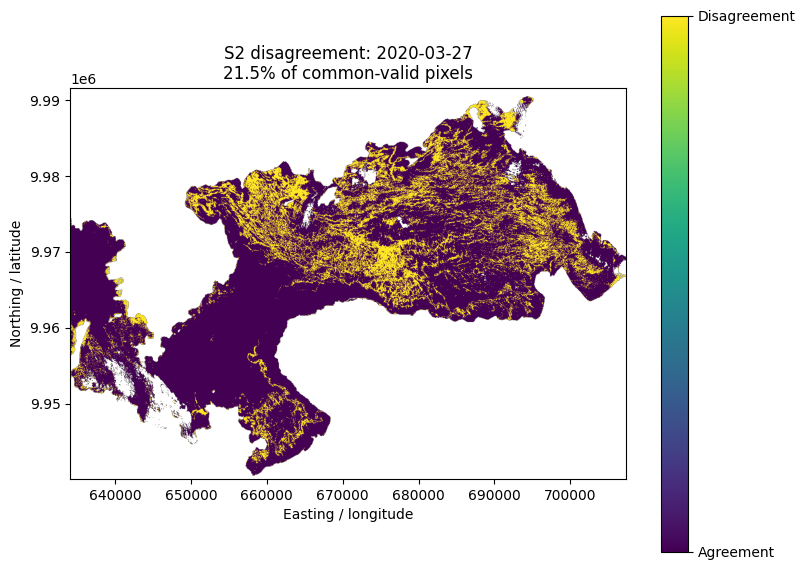

In [14]:
def plot_disagreement_quicklook(scene_row):
    tif = Path(scene_row["disagreement_tif"])
    if not tif.exists():
        return None

    local = staged_copy(tif)

    with rasterio.open(local) as src:
        scale = max(
            src.width / 1200,
            src.height / 1200,
            1,
        )

        out_w = max(1, int(src.width / scale))
        out_h = max(1, int(src.height / scale))

        arr = src.read(
            1,
            out_shape=(out_h, out_w),
            resampling=Resampling.nearest,
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

    binary = np.full(arr.shape, np.nan, dtype=float)
    binary[arr == 0] = 0.0
    binary[
        (arr != 0) & (arr != NODATA_VALUE)
    ] = 1.0

    fig, ax = plt.subplots(figsize=(8.2, 5.8))

    im = ax.imshow(
        binary,
        extent=extent,
        origin="upper",
    )

    ax.set_xlabel("Easting / longitude")
    ax.set_ylabel("Northing / latitude")
    ax.set_title(
        f"{scene_row['sensor']} disagreement: "
        f"{scene_row['start_date'].date()}\n"
        f"{100 * scene_row['disagreement_fraction']:.1f}% "
        "of common-valid pixels"
    )

    cbar = fig.colorbar(
        im,
        ax=ax,
        ticks=[0, 1],
    )
    cbar.ax.set_yticklabels(
        ["Agreement", "Disagreement"]
    )

    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{scene_row['sensor'].lower()}_"
        f"{scene_row['start_date'].date()}_"
        "rules_vs_lr_disagreement.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    top = (
        scene_df[
            scene_df["sensor"] == sensor
        ]
        .sort_values(
            "disagreement_fraction",
            ascending=False,
        )
        .head(N_TOP_DISAGREEMENT_QUICKLOOKS)
    )

    for _, row in top.iterrows():
        plot_disagreement_quicklook(row)

## 11. Transition legend for disagreement GeoTIFFs

This table can be used to interpret raster values in QGIS. The legend is emitted **per sensor**, because the same transition value carries different class meanings under the S2 and S1 class codings.

In [15]:
legend_rows = []

for sensor in SENSOR_FILTER:
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    legend_rows.append({
        "sensor": sensor,
        "value": 0,
        "meaning": "Agreement",
        "lr_code": np.nan,
        "lr_class": "",
        "rule_code": np.nan,
        "rule_class": "",
    })

    for lr_code in class_codes:
        for rule_code in class_codes:
            if lr_code == rule_code:
                continue

            value = (
                10 * (lr_code + 1)
                + (rule_code + 1)
            )

            legend_rows.append({
                "sensor": sensor,
                "value": value,
                "meaning": (
                    f"LR: {class_labels[lr_code]} -> "
                    f"Rules: {class_labels[rule_code]}"
                ),
                "lr_code": lr_code,
                "lr_class": class_labels[lr_code],
                "rule_code": rule_code,
                "rule_class": class_labels[rule_code],
            })

legend_df = pd.DataFrame(legend_rows).sort_values(
    ["sensor", "value"]
).reset_index(drop=True)

legend_df.to_csv(
    TABLE_DIR / "rules_vs_lr_disagreement_transition_legend.csv",
    index=False,
)

display(legend_df)

,sensor,value,meaning,lr_code,lr_class,rule_code,rule_class
0,S1,0,Agreement,NaN,,NaN,
1,S1,12,LR: Open water / surface algae -> Rules: LEV,0.0,Open water / surface algae,1.0,LEV
2,S1,13,LR: Open water / surface algae -> Rules: Floating plants,0.0,Open water / surface algae,2.0,Floating plants
3,S1,21,LR: LEV -> Rules: Open water / surface algae,1.0,LEV,0.0,Open water / surface algae
4,S1,23,LR: LEV -> Rules: Floating plants,1.0,LEV,2.0,Floating plants
5,S1,31,LR: Floating plants -> Rules: Open water / surface algae,2.0,Floating plants,0.0,Open water / surface algae
6,S1,32,LR: Floating plants -> Rules: LEV,2.0,Floating plants,1.0,LEV
7,S2,0,Agreement,NaN,,NaN,
8,S2,12,LR: Open water -> Rules: LEV,0.0,Open water,1.0,LEV
9,S2,13,LR: Open water -> Rules: Floating plants,0.0,Open water,2.0,Floating plants


## 12. Compact dissertation reporting table

This is deliberately descriptive and does not treat the rules-based classifier as a validation reference.

In [16]:
report_rows = []

for sensor in SENSOR_FILTER:
    ss = scene_df[
        scene_df["sensor"] == sensor
    ]

    if ss.empty:
        continue

    pooled = pooled_matrices[sensor]
    pooled_total = pooled.sum()

    report_rows.append({
        "Sensor": sensor,
        "Paired scenes": len(ss),
        "Pooled pixel agreement": (
            np.trace(pooled) / pooled_total
            if pooled_total else np.nan
        ),
        "Pooled Cohen kappa": (
            cohen_kappa_from_matrix(pooled)
        ),
        "Median scene agreement": (
            ss["overall_agreement"].median()
        ),
        "Median scene kappa": (
            ss["cohen_kappa"].median()
        ),
        "Mean floating IoU": (
            ss["floating_iou"].mean()
        ),
        "Mean floating Dice": (
            ss["floating_dice"].mean()
        ),
        "Mean LR floating area (ha)": (
            ss["floating_lr_area_ha"].mean()
        ),
        "Mean rules floating area (ha)": (
            ss["floating_rule_area_ha"].mean()
        ),
        "Mean LR-rules floating difference (ha)": (
            ss["floating_area_difference_lr_minus_rules_ha"].mean()
        ),
        "Mean absolute floating difference (ha)": (
            ss["floating_absolute_area_difference_ha"].mean()
        ),
    })

report_df = pd.DataFrame(report_rows)

report_df.to_csv(
    TABLE_DIR / "rules_vs_lr_dissertation_summary.csv",
    index=False,
)

display(report_df.round(4))

,Sensor,Paired scenes,Pooled pixel agreement,Pooled Cohen kappa,Median scene agreement,Median scene kappa,Mean floating IoU,Mean floating Dice,Mean LR floating area (ha),Mean rules floating area (ha),Mean LR-rules floating difference (ha),Mean absolute floating difference (ha)
0,S2,372,0.9421,0.3745,0.9575,0.4107,0.4979,0.6251,909.8546,1176.3596,-266.5049,329.9154


## 13. Accuracy against labelled reference points

Sections 4–12 measure **concordance** between two classifiers. This section measures
**accuracy**: it scores the rules-based classifier against the labelled reference
points that `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb` trains and
cross-validates on (`SV_S2_Training.csv` / `SV_S1_Training.csv`), using the same
metric suite that notebook applies to every candidate model.

The metrics are copied verbatim from `_score_split()` in the classifier notebook, so
a rules row can sit in the same table as Random Forest, Extra Trees, Gradient
Boosting and Logistic Regression:

`accuracy`, `balanced_accuracy`, `kappa`, `macro_f1`, `weighted_f1`,
`floating_precision`, `floating_recall`, `floating_f1`, `floating_support`.

Three evaluation routes are run, because they answer different questions:

| Route | What is scored | Comparable to |
| --- | --- | --- |
| **Predictor space** (13a–13e) | The rule thresholds replayed on the original `SV_S2_Training.csv` / `SV_S1_Training.csv` points' own predictor values | Other rules-based results on that same original point set |
| **Map space** (13f) | The classified rasters this notebook already compares, sampled at the reference points | The rules-based **and** Logistic Regression maps, on identical points |
| **S2 fixed validation** (13h) | Both classifiers on the identical held-out points of the expanded manual-corrections dataset | Each other — **this is the primary like-for-like threshold-versus-ML accuracy comparison** |

### What these numbers are, and are not

- In 13a–13f the reference points are the classifier's original **training** labels
  (`SV_S2_Training.csv` / `SV_S1_Training.csv`). They are labelled data, so accuracy
  can be measured against them — but they are not an independent validation set.
- Those original points are **not** the dataset the corrected Logistic Regression
  model is trained and validated on. That model uses the expanded manual-corrections
  dataset, so a rules row from 13c or 13d is **not** directly comparable to the
  expanded-data Logistic Regression result: the two are scored against different
  reference data. Section 13h is where the two classifiers meet on one identical set
  of points.
- The rules-based classifier has **no fitted parameters**, so it never saw any of
  these points in a way that could flatter it: its pooled score and its held-out-fold
  score measure the same thing. The models' map-space scores in 13f are **not**
  held-out, because Logistic Regression was fitted on those very points, so 13f
  flatters the model and not the rules.
- Sentinel-1 rule replay in predictor space uses the CSV's `VH_corrected`, whereas
  the deployed S1 model is trained on Earth-Engine SCC re-sampled backscatter
  (classifier notebook section 7). The map-space route in 13f avoids that
  discrepancy, because it reads the rasters the rules actually produced.
- The fixed-validation route in 13h is **S2 only**. There is no equivalent expanded
  fixed-validation dataset for S1, and none should be implied.

In [17]:
# ---------------------------------------------------------------------
# Section 13 configuration: accuracy against labelled reference points
# ---------------------------------------------------------------------
RUN_ACCURACY_EVALUATION = True

# The labelled points the classifier notebook trains on (its S2_CSV / S1_CSV).
REFERENCE_CSV = {
    "S2": CLASSIFIER_ROOT / "SV_S2_Training.csv",
    "S1": CLASSIFIER_ROOT / "SV_S1_Training.csv",
}

REFERENCE_LABEL_COLUMN = "dominant_class"
REFERENCE_CLASS_COLUMN = "class"
REFERENCE_LOCATION_FILTER = "Winam"

# Copied from S2_RAW_CLASS_MAPPING / S1_RAW_CLASS_MAPPING in the classifier
# notebook. S2 excludes 'F1' and S1 excludes 'F2': a raw label with no entry here
# is dropped, exactly as prepare_route_b_raw_df() drops it before training.
REFERENCE_RAW_CLASS_MAPPING = {
    "S2": {"W": 0, "T": 1, "F2": 2, "A": 3},
    "S1": {"W": 0, "A": 0, "T": 1, "F1": 2},
}

# Columns each sensor's rule branch reads. A point missing any of them cannot be
# rule-classified and is reported as unevaluable rather than silently scored.
RULE_PREDICTOR_COLUMNS = {
    "S2": ("AWEI_p95", "AWEI", "NDMI"),
    "S1": ("VH_p5", "VH_corrected"),
}

# Rule thresholds, copied from classify_s2_rules_array / classify_s1_rules_array.
S2_RULE_NDMI_ALGAE = 0.63
S2_RULE_NDMI_FLOATING = 0.10
S1_RULE_VH_P5_LEV_DB = -17.0
S1_RULE_VH_FLOATING_DB = -14.0

# Spatial block CV settings, copied from the classifier notebook so the rules row
# is aggregated over folds built the same way as every model row.
SPATIAL_BLOCK_DEGREES = 0.1
ACCURACY_CV_N_SPLITS = 5
ACCURACY_CV_N_REPEATS = 10
ACCURACY_CV_RANDOM_STATE = 42

# The metric suite from _score_split(); floating_support is carried separately
# because the classifier notebook aggregates these eight only.
ACCURACY_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "kappa",
    "macro_f1",
    "weighted_f1",
    "floating_precision",
    "floating_recall",
    "floating_f1",
]

# The classifier notebook selects its production model on floating_f1.
ACCURACY_LEADERBOARD_SORT_METRIC = "floating_f1"

RULES_MODEL_NAME = "Rules-based (paper thresholds)"
LR_MODEL_NAME = "Logistic Regression"

# Optional: fold the rules row into the classifier notebook's own CV leaderboard.
CLASSIFIER_CV_RESULTS_DIR = CLASSIFIER_ROOT / "outputs"
CLASSIFIER_CV_RESULTS_GLOB = "winam_classifier_spatial_cv_*.csv"

# Map-space route: sample the classified rasters at the reference points. A point
# matches a scene when its acquisition date falls inside the scene period, widened
# by this tolerance.
SAMPLE_MAPS_AT_REFERENCE_POINTS = True
MAP_MATCH_TOLERANCE_DAYS = 0

print("Reference point CSVs:")
for _sensor, _path in REFERENCE_CSV.items():
    print(f" - {_sensor}: {_path} (exists: {Path(_path).exists()})")

Reference point CSVs:
 - S2: /content/drive/MyDrive/Winam_RF_Training_Data/SV_S2_Training.csv (exists: True)
 - S1: /content/drive/MyDrive/Winam_RF_Training_Data/SV_S1_Training.csv (exists: True)


### 13a. Reference points and rule replay

The cleaning is the classifier notebook's `prepare_route_b_raw_df()`: map the raw
label to a class code, drop unmapped labels and rows without geometry, then keep the
`Winam` rows. The rule functions are line-for-line replays of
`classify_s2_rules_array()` / `classify_s1_rules_array()` — the same thresholds in
the same order, so a point is labelled the way the corresponding raster pixel was.

In [18]:
def extract_lonlat_from_geo(geo_value):
    """Return (lon, lat) from a CSV `.geo` cell. Copied from the classifier notebook."""
    geom = json.loads(geo_value) if isinstance(geo_value, str) else geo_value
    if isinstance(geom, dict):
        if geom.get("type") == "Point":
            lon, lat = geom["coordinates"][:2]
            return float(lon), float(lat)
        if geom.get("type") == "Feature":
            lon, lat = geom["geometry"]["coordinates"][:2]
            return float(lon), float(lat)
    coords = geom["coordinates"]
    return float(coords[0]), float(coords[1])


def assign_spatial_blocks(df, block_degrees=SPATIAL_BLOCK_DEGREES):
    """Add the classifier notebook's spatial block id to each reference point."""
    lon_bin = np.floor(df["lon"].astype(float) / block_degrees).astype(np.int64)
    lat_bin = np.floor(df["lat"].astype(float) / block_degrees).astype(np.int64)
    return (lon_bin * 100000 + lat_bin).astype(np.int64)


def s2_rule_class_at_points(df, nodata_value=NODATA_VALUE):
    """Replay classify_s2_rules_array() on point predictor values.

    Same branch order as the raster function: every valid point starts as LEV,
    then the water-body branches overwrite it. A point missing any predictor is
    returned as `nodata_value`, mirroring an invalid pixel.
    """
    awei_p95 = df["AWEI_p95"].to_numpy(dtype=np.float64)
    awei = df["AWEI"].to_numpy(dtype=np.float64)
    ndmi = df["NDMI"].to_numpy(dtype=np.float64)

    valid = np.isfinite(awei_p95) & np.isfinite(awei) & np.isfinite(ndmi)

    classified = np.full(valid.shape, nodata_value, dtype=np.uint8)
    classified[valid] = 1
    valid_waterbody = valid & (awei_p95 >= 0)
    classified[valid_waterbody & (awei >= 0)] = 0
    classified[valid_waterbody & (awei < 0) & (ndmi >= S2_RULE_NDMI_ALGAE)] = 3
    classified[
        valid_waterbody
        & (awei < 0)
        & (ndmi >= S2_RULE_NDMI_FLOATING)
        & (ndmi < S2_RULE_NDMI_ALGAE)
    ] = 2
    return classified


def s1_rule_class_at_points(df, vh_column="VH_corrected", nodata_value=NODATA_VALUE):
    """Replay classify_s1_rules_array() on point predictor values."""
    vh_p5 = df["VH_p5"].to_numpy(dtype=np.float64)
    vh = df[vh_column].to_numpy(dtype=np.float64)

    valid = np.isfinite(vh_p5) & np.isfinite(vh)

    classified = np.full(valid.shape, nodata_value, dtype=np.uint8)
    classified[valid] = 0
    lev = valid & (vh_p5 > S1_RULE_VH_P5_LEV_DB)
    classified[lev] = 1
    classified[valid & (~lev) & (vh > S1_RULE_VH_FLOATING_DB)] = 2
    return classified


RULE_CLASSIFIER_AT_POINTS = {
    "S2": s2_rule_class_at_points,
    "S1": s1_rule_class_at_points,
}


def load_reference_points(sensor):
    """Load, clean and rule-classify one sensor's labelled reference points.

    Returns None (with an explanatory message) when the CSV or the rule predictor
    columns are absent, so the accuracy section degrades instead of aborting a run
    whose concordance outputs are already written.
    """
    path = Path(REFERENCE_CSV[sensor])
    if not path.exists():
        print(f"{sensor}: reference CSV not found ({path}); skipping.")
        return None

    df = pd.read_csv(path)

    missing = [c for c in RULE_PREDICTOR_COLUMNS[sensor] if c not in df.columns]
    if missing:
        print(f"{sensor}: reference CSV is missing rule predictors {missing}; skipping.")
        return None
    if REFERENCE_LABEL_COLUMN not in df.columns or ".geo" not in df.columns:
        print(
            f"{sensor}: reference CSV needs {REFERENCE_LABEL_COLUMN!r} and '.geo'; skipping."
        )
        return None

    if "Date" in df.columns:
        df["date"] = pd.to_datetime(df["Date"], errors="coerce").dt.strftime("%Y-%m-%d")

    df[REFERENCE_CLASS_COLUMN] = df[REFERENCE_LABEL_COLUMN].map(
        REFERENCE_RAW_CLASS_MAPPING[sensor]
    )
    df = df.dropna(subset=[REFERENCE_CLASS_COLUMN, ".geo"]).copy()
    df[REFERENCE_CLASS_COLUMN] = df[REFERENCE_CLASS_COLUMN].astype(int)

    if REFERENCE_LOCATION_FILTER is not None and "Location" in df.columns:
        df = df[df["Location"].astype(str).eq(REFERENCE_LOCATION_FILTER)].copy()

    if df.empty:
        print(f"{sensor}: no reference points survived cleaning; skipping.")
        return None

    lonlat = df[".geo"].apply(extract_lonlat_from_geo)
    df["lon"] = [ll[0] for ll in lonlat]
    df["lat"] = [ll[1] for ll in lonlat]
    df["spatial_block"] = assign_spatial_blocks(df)

    rule_code = RULE_CLASSIFIER_AT_POINTS[sensor](df)

    out = pd.DataFrame({
        "sensor": sensor,
        "reference_label": df[REFERENCE_LABEL_COLUMN].astype(str).to_numpy(),
        "reference_code": df[REFERENCE_CLASS_COLUMN].to_numpy(),
        "rule_code": rule_code.astype(np.int64),
        "lon": df["lon"].to_numpy(),
        "lat": df["lat"].to_numpy(),
        "spatial_block": df["spatial_block"].to_numpy(),
        "date": df["date"].to_numpy() if "date" in df.columns else pd.NaT,
    })
    out["reference_class"] = out["reference_code"].map(class_labels_for(sensor))
    out["rule_evaluable"] = out["rule_code"].ne(NODATA_VALUE)
    out["rule_class"] = out["rule_code"].map(class_labels_for(sensor))
    return out

In [19]:
reference_frames = []

if RUN_ACCURACY_EVALUATION:
    for sensor in SENSOR_FILTER:
        loaded = load_reference_points(sensor)
        if loaded is not None:
            reference_frames.append(loaded)
else:
    print("RUN_ACCURACY_EVALUATION is False; section 13 is skipped.")

reference_points = (
    pd.concat(reference_frames, ignore_index=True)
    if reference_frames else pd.DataFrame()
)

ACCURACY_AVAILABLE = not reference_points.empty

if ACCURACY_AVAILABLE:
    reference_points.to_csv(
        TABLE_DIR / "rules_accuracy_reference_points.csv",
        index=False,
    )

    print("Reference points loaded:")
    display(
        reference_points.groupby("sensor")
        .agg(
            points=("reference_code", "size"),
            rule_evaluable=("rule_evaluable", "sum"),
            spatial_blocks=("spatial_block", "nunique"),
            classes=("reference_code", "nunique"),
        )
        .reset_index()
    )

    print("\nReference class counts:")
    display(
        reference_points.groupby(["sensor", "reference_code", "reference_class"])
        .size()
        .rename("points")
        .reset_index()
    )

    unevaluable = reference_points[~reference_points["rule_evaluable"]]
    if not unevaluable.empty:
        print(
            f"\n{len(unevaluable)} point(s) lack a complete rule predictor set and are "
            "excluded from every accuracy metric below:"
        )
        display(unevaluable.groupby("sensor").size().rename("points").reset_index())
else:
    print("No reference points available; section 13 produces no accuracy outputs.")

Reference points loaded:


,sensor,points,rule_evaluable,spatial_blocks,classes
0,S1,236,236,25,3
1,S2,238,238,25,4



Reference class counts:


,sensor,reference_code,reference_class,points
0,S1,0,Open water / surface algae,119
1,S1,1,LEV,57
2,S1,2,Floating plants,60
3,S2,0,Open water,61
4,S2,1,LEV,57
5,S2,2,Floating plants,60
6,S2,3,Surface algae,60


### 13b. Metric helpers

`classification_metrics()` returns exactly the keys `_score_split()` returns in the
classifier notebook, computed with the same scikit-learn calls, the same
`zero_division=0` convention and the same sensor-specific `labels` list — so
$\kappa$ is computed over the sensor's full class scheme even when a fold happens to
contain no surface-algae point.

`spatial_block_folds()` reproduces the classifier notebook's repeated grouped
k-fold: shuffle the blocks, deal them round-robin into folds, repeat. A block never
straddles the train/test boundary.

In [20]:
def classification_metrics(y_true, y_pred, labels, floating_code=FLOATING_CLASS_CODE):
    """The `_score_split()` metric suite from the classifier notebook."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    precision, recall, floating_f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[floating_code], zero_division=0
    )

    return {
        "n_points": int(y_true.size),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred, labels=labels),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "floating_precision": precision[0],
        "floating_recall": recall[0],
        "floating_f1": floating_f1[0],
        "floating_support": int(support[0]),
    }


def per_class_metrics(y_true, y_pred, sensor, classifier, evaluation):
    """Per-class precision/recall/F1, also named as user's/producer's accuracy."""
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(class_codes), zero_division=0
    )

    y_pred = np.asarray(y_pred)

    rows = []
    for i, code in enumerate(class_codes):
        rows.append({
            "sensor": sensor,
            "classifier": classifier,
            "evaluation": evaluation,
            "class_code": code,
            "class_name": class_labels[code],
            "reference_points": int(support[i]),
            "predicted_points": int((y_pred == code).sum()),
            # In the remote-sensing accuracy literature precision is the user's
            # accuracy of the mapped class and recall its producer's accuracy.
            "precision_users_accuracy": precision[i],
            "recall_producers_accuracy": recall[i],
            "f1": f1[i],
        })
    return rows


def confusion_long_form(y_true, y_pred, sensor, classifier, evaluation):
    """Long-form reference x prediction confusion matrix for one classifier."""
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    matrix = confusion_matrix(y_true, y_pred, labels=list(class_codes))

    rows = []
    for i, reference_code in enumerate(class_codes):
        row_total = matrix[i].sum()
        for j, predicted_code in enumerate(class_codes):
            count = int(matrix[i, j])
            rows.append({
                "sensor": sensor,
                "classifier": classifier,
                "evaluation": evaluation,
                "reference_code": reference_code,
                "reference_class": class_labels[reference_code],
                "predicted_code": predicted_code,
                "predicted_class": class_labels[predicted_code],
                "points": count,
                "row_percent": (100.0 * count / row_total) if row_total else np.nan,
            })
    return rows, matrix


def spatial_block_folds(groups, n_splits=ACCURACY_CV_N_SPLITS,
                        n_repeats=ACCURACY_CV_N_REPEATS,
                        random_state=ACCURACY_CV_RANDOM_STATE):
    """Yield (repeat, fold, test_idx) for the classifier notebook's grouped CV."""
    groups = np.asarray(groups)
    rng = np.random.default_rng(random_state)
    unique_groups = np.unique(groups)

    if len(unique_groups) < n_splits:
        raise ValueError(
            f"Only {len(unique_groups)} spatial blocks but n_splits={n_splits}. "
            "Reduce SPATIAL_BLOCK_DEGREES (smaller blocks) or ACCURACY_CV_N_SPLITS."
        )

    for repeat in range(n_repeats):
        shuffled = rng.permutation(unique_groups)
        group_to_fold = {g: i % n_splits for i, g in enumerate(shuffled)}
        fold_assignments = np.array([group_to_fold[g] for g in groups])

        for fold in range(n_splits):
            test_idx = np.where(fold_assignments == fold)[0]
            train_idx = np.where(fold_assignments != fold)[0]
            if len(test_idx) == 0 or len(train_idx) == 0:
                continue
            yield repeat, fold, test_idx


def aggregate_fold_metrics(per_fold_df, sensor, model_name):
    """Mean/std over folds in the classifier notebook's leaderboard schema."""
    agg = {
        "sensor": sensor,
        "model": model_name,
        "n_folds_evaluated": len(per_fold_df),
    }
    for metric in ACCURACY_METRICS:
        agg[f"{metric}_mean"] = per_fold_df[metric].mean()
        agg[f"{metric}_std"] = per_fold_df[metric].std()
    return agg

### 13c. Pooled accuracy of the rules-based classifier

Every evaluable reference point, scored once. Because the rules have no fitted
parameters, this pooled score is not optimistic — there is nothing to overfit — so it
is the number to quote for the rules-based classifier itself.

In [21]:
rules_pooled_rows = []
rules_per_class_rows = []
rules_confusion_rows = []
rules_confusion_matrices = {}

EVALUATION_PREDICTOR_SPACE = "reference points (predictor space)"

if ACCURACY_AVAILABLE:
    for sensor in SENSOR_FILTER:
        points = reference_points[
            reference_points["sensor"].eq(sensor)
            & reference_points["rule_evaluable"]
        ]

        if points.empty:
            print(f"{sensor}: no evaluable reference points; skipping pooled accuracy.")
            continue

        labels = list(class_codes_for(sensor))
        y_true = points["reference_code"].to_numpy()
        y_pred = points["rule_code"].to_numpy()

        rules_pooled_rows.append({
            "sensor": sensor,
            "classifier": RULES_MODEL_NAME,
            "evaluation": EVALUATION_PREDICTOR_SPACE,
            "spatial_blocks": int(points["spatial_block"].nunique()),
            **classification_metrics(y_true, y_pred, labels),
        })

        rules_per_class_rows.extend(
            per_class_metrics(
                y_true, y_pred, sensor,
                classifier=RULES_MODEL_NAME,
                evaluation=EVALUATION_PREDICTOR_SPACE,
            )
        )

        confusion_rows, matrix = confusion_long_form(
            y_true, y_pred, sensor,
            classifier=RULES_MODEL_NAME,
            evaluation=EVALUATION_PREDICTOR_SPACE,
        )
        rules_confusion_rows.extend(confusion_rows)
        rules_confusion_matrices[sensor] = matrix

rules_accuracy_pooled_df = pd.DataFrame(rules_pooled_rows)
rules_accuracy_per_class_df = pd.DataFrame(rules_per_class_rows)
rules_accuracy_confusion_df = pd.DataFrame(rules_confusion_rows)

if not rules_accuracy_pooled_df.empty:
    rules_accuracy_pooled_df.to_csv(
        TABLE_DIR / "rules_accuracy_pooled.csv", index=False)
    rules_accuracy_per_class_df.to_csv(
        TABLE_DIR / "rules_accuracy_per_class.csv", index=False)
    rules_accuracy_confusion_df.to_csv(
        TABLE_DIR / "rules_accuracy_confusion_matrix.csv", index=False)

    print("Rules-based classifier accuracy at the labelled reference points:")
    display(rules_accuracy_pooled_df.round(4))

    print("\nPer-class accuracy:")
    display(rules_accuracy_per_class_df.round(4))

Rules-based classifier accuracy at the labelled reference points:


,sensor,classifier,evaluation,spatial_blocks,n_points,accuracy,balanced_accuracy,kappa,macro_f1,weighted_f1,floating_precision,floating_recall,floating_f1,floating_support
0,S2,Rules-based (paper thresholds),reference points (predictor space),25,238,0.9580,0.9575,0.9440,0.9578,0.9578,0.9492,0.9333,0.9412,60
1,S1,Rules-based (paper thresholds),reference points (predictor space),25,236,0.8983,0.8793,0.8339,0.8889,0.8961,0.9184,0.7500,0.8257,60



Per-class accuracy:


,sensor,classifier,evaluation,class_code,class_name,reference_points,predicted_points,precision_users_accuracy,recall_producers_accuracy,f1
0,S2,Rules-based (paper thresholds),reference points (predictor space),0,Open water,61,63,0.9524,0.9836,0.9677
1,S2,Rules-based (paper thresholds),reference points (predictor space),1,LEV,57,54,0.9815,0.9298,0.9550
2,S2,Rules-based (paper thresholds),reference points (predictor space),2,Floating plants,60,59,0.9492,0.9333,0.9412
3,S2,Rules-based (paper thresholds),reference points (predictor space),3,Surface algae,60,62,0.9516,0.9833,0.9672
4,S1,Rules-based (paper thresholds),reference points (predictor space),0,Open water / surface algae,119,129,0.8837,0.9580,0.9194
5,S1,Rules-based (paper thresholds),reference points (predictor space),1,LEV,57,58,0.9138,0.9298,0.9217
6,S1,Rules-based (paper thresholds),reference points (predictor space),2,Floating plants,60,49,0.9184,0.7500,0.8257


### 13d. Spatial-block cross-validated accuracy

The same repeated grouped k-fold the classifier notebook uses to score its candidate
models, applied to the rules. Each fold's held-out blocks are scored, then the folds
are averaged, giving `{metric}_mean` and `{metric}_std` columns in the same schema as
`winam_classifier_spatial_cv_*.csv`.

For a parameter-free classifier the fold mean is close to the pooled score by
construction; the value of running it is that the **spread** is measured over spatial
folds built the same way as the models'. When the classifier notebook's CV table is on
Drive, the rules row is merged into it.

> **This is not yet a like-for-like accuracy contest.** The rules row here is scored on
> the original `SV_S2_Training.csv` / `SV_S1_Training.csv` points, whereas the model
> rows in `winam_classifier_spatial_cv_*.csv` are scored on the expanded
> manual-corrections dataset. The fold construction matches; the reference dataset does
> not. Read this table as the rules' own cross-validated performance and as a rough
> leaderboard placement — the paired contest against the expanded-data Logistic
> Regression model is section 13h.

In [22]:
rules_cv_fold_rows = []
rules_cv_rows = []

if ACCURACY_AVAILABLE:
    for sensor in SENSOR_FILTER:
        points = reference_points[
            reference_points["sensor"].eq(sensor)
            & reference_points["rule_evaluable"]
        ].reset_index(drop=True)

        if points.empty:
            continue

        labels = list(class_codes_for(sensor))
        y_true = points["reference_code"].to_numpy()
        y_pred = points["rule_code"].to_numpy()
        groups = points["spatial_block"].to_numpy()

        try:
            folds = list(spatial_block_folds(groups))
        except ValueError as exc:
            print(f"{sensor}: skipping spatial CV — {exc}")
            continue

        fold_rows = []
        for repeat, fold, test_idx in folds:
            metrics = classification_metrics(
                y_true[test_idx], y_pred[test_idx], labels
            )
            metrics.update({
                "sensor": sensor,
                "model": RULES_MODEL_NAME,
                "repeat": repeat,
                "fold": fold,
                "test_blocks": int(pd.unique(groups[test_idx]).size),
            })
            fold_rows.append(metrics)

        per_fold_df = pd.DataFrame(fold_rows)
        rules_cv_fold_rows.extend(fold_rows)
        rules_cv_rows.append(
            aggregate_fold_metrics(per_fold_df, sensor, RULES_MODEL_NAME)
        )

rules_accuracy_cv_df = pd.DataFrame(rules_cv_rows)
rules_accuracy_cv_folds_df = pd.DataFrame(rules_cv_fold_rows)

if not rules_accuracy_cv_df.empty:
    rules_accuracy_cv_df.to_csv(
        TABLE_DIR / "rules_accuracy_spatial_cv.csv", index=False)
    rules_accuracy_cv_folds_df.to_csv(
        TABLE_DIR / "rules_accuracy_spatial_cv_folds.csv", index=False)

    print("Rules-based classifier, spatial-block CV (same folds as the model CV):")
    display(rules_accuracy_cv_df.round(4))

Rules-based classifier, spatial-block CV (same folds as the model CV):


,sensor,model,n_folds_evaluated,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,kappa_mean,kappa_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,floating_precision_mean,floating_precision_std,floating_recall_mean,floating_recall_std,floating_f1_mean,floating_f1_std
0,S2,Rules-based (paper thresholds),50,0.9559,0.0298,0.9522,0.0406,0.9394,0.0419,0.9504,0.0416,0.9556,0.0301,0.9137,0.1666,0.8875,0.1805,0.8983,0.1696
1,S1,Rules-based (paper thresholds),50,0.9005,0.0432,0.8840,0.0467,0.8356,0.0671,0.8878,0.0446,0.8983,0.0448,0.9088,0.1128,0.7525,0.1339,0.8160,0.1010


In [23]:
def load_classifier_cv_results():
    """Most recent winam_classifier_spatial_cv_*.csv written by the classifier notebook."""
    directory = Path(CLASSIFIER_CV_RESULTS_DIR)
    if not directory.exists():
        print(f"Classifier CV directory not found: {directory}")
        return None

    matches = sorted(directory.glob(CLASSIFIER_CV_RESULTS_GLOB))
    if not matches:
        print(
            f"No {CLASSIFIER_CV_RESULTS_GLOB} in {directory}; the leaderboard will "
            "contain the rules row only."
        )
        return None

    latest = max(matches, key=lambda p: p.stat().st_mtime)
    print("Model spatial CV results:", latest)
    return pd.read_csv(latest)


def sensor_key_from_label(label):
    """'S2 Route B' -> 'S2'; the classifier notebook labels sensors verbosely."""
    text = str(label).strip().upper()
    for sensor in SENSOR_FILTER:
        if text.startswith(sensor.upper()):
            return sensor
    return str(label)


LEADERBOARD_COLUMNS = (
    ["sensor_key", "sensor", "model", "n_folds_evaluated"]
    + [f"{metric}_{stat}" for metric in ACCURACY_METRICS for stat in ("mean", "std")]
)

leaderboard_df = pd.DataFrame()

if not rules_accuracy_cv_df.empty:
    frames = []

    model_cv = load_classifier_cv_results()
    if model_cv is not None and not model_cv.empty:
        model_cv = model_cv.copy()
        model_cv["sensor_key"] = model_cv["sensor"].apply(sensor_key_from_label)
        frames.append(model_cv.reindex(columns=LEADERBOARD_COLUMNS))

    rules_rows = rules_accuracy_cv_df.copy()
    rules_rows["sensor_key"] = rules_rows["sensor"]
    frames.append(rules_rows.reindex(columns=LEADERBOARD_COLUMNS))

    leaderboard_df = (
        pd.concat(frames, ignore_index=True)
        .sort_values(
            ["sensor_key", f"{ACCURACY_LEADERBOARD_SORT_METRIC}_mean"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    leaderboard_df.to_csv(
        TABLE_DIR / "rules_vs_models_spatial_cv_leaderboard.csv", index=False)

    print(
        f"\nSpatial-CV leaderboard, sorted by {ACCURACY_LEADERBOARD_SORT_METRIC}_mean "
        "within each sensor:"
    )
    display(leaderboard_df.round(4))

Model spatial CV results: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_classifier_spatial_cv_route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.csv

Spatial-CV leaderboard, sorted by floating_f1_mean within each sensor:


,sensor_key,sensor,model,n_folds_evaluated,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,kappa_mean,kappa_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,floating_precision_mean,floating_precision_std,floating_recall_mean,floating_recall_std,floating_f1_mean,floating_f1_std
0,S1,S1 Route B SCC,Logistic Regression baseline,50,0.9604,0.0226,0.9563,0.0271,0.9354,0.0366,0.9562,0.0245,0.9604,0.0226,0.9767,0.0365,0.9316,0.0652,0.9517,0.0352
1,S1,S1 Route B SCC,Extra Trees,50,0.9606,0.0302,0.9544,0.0348,0.9368,0.0474,0.9572,0.0321,0.9606,0.0301,0.9785,0.0446,0.9157,0.0755,0.9448,0.0535
2,S1,S1 Route B SCC,Class-weighted RF,50,0.9579,0.0287,0.9522,0.0341,0.9318,0.0453,0.9547,0.0312,0.9575,0.0290,0.9680,0.0491,0.9100,0.0871,0.9357,0.0553
3,S1,S1 Route B SCC,Random Forest,50,0.9550,0.0306,0.9462,0.0401,0.9276,0.0475,0.9497,0.0341,0.9548,0.0304,0.9631,0.0528,0.9026,0.1035,0.9273,0.0680
4,S1,S1 Route B SCC,Hist Gradient Boosting,50,0.9491,0.0332,0.9444,0.0344,0.9183,0.0513,0.9454,0.0341,0.9490,0.0332,0.9563,0.0522,0.9031,0.0833,0.9257,0.0476
5,S1,S1 Route B SCC,Gradient Boosting,50,0.9345,0.0452,0.9257,0.0495,0.8944,0.0703,0.9283,0.0483,0.9341,0.0452,0.9396,0.0722,0.8844,0.1107,0.9055,0.0715
6,S1,S1,Rules-based (paper thresholds),50,0.9005,0.0432,0.8840,0.0467,0.8356,0.0671,0.8878,0.0446,0.8983,0.0448,0.9088,0.1128,0.7525,0.1339,0.8160,0.1010
7,S2,S2 Route B,Extra Trees,50,0.8445,0.0783,0.8396,0.0647,0.7794,0.1046,0.8187,0.0753,0.8451,0.0798,0.8880,0.0971,0.9620,0.0342,0.9199,0.0548
8,S2,S2 Route B,Random Forest,50,0.8245,0.1030,0.8244,0.0876,0.7519,0.1376,0.7964,0.1029,0.8230,0.1055,0.8873,0.1099,0.9599,0.0358,0.9176,0.0635
9,S2,S2 Route B,Logistic Regression baseline,50,0.8600,0.0514,0.8612,0.0574,0.8014,0.0699,0.8344,0.0561,0.8639,0.0514,0.9522,0.0457,0.8874,0.0658,0.9174,0.0476


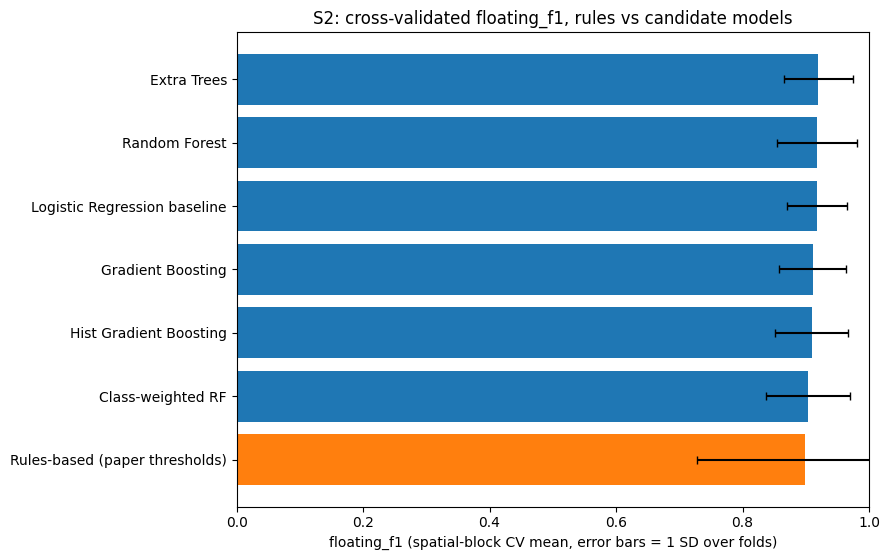

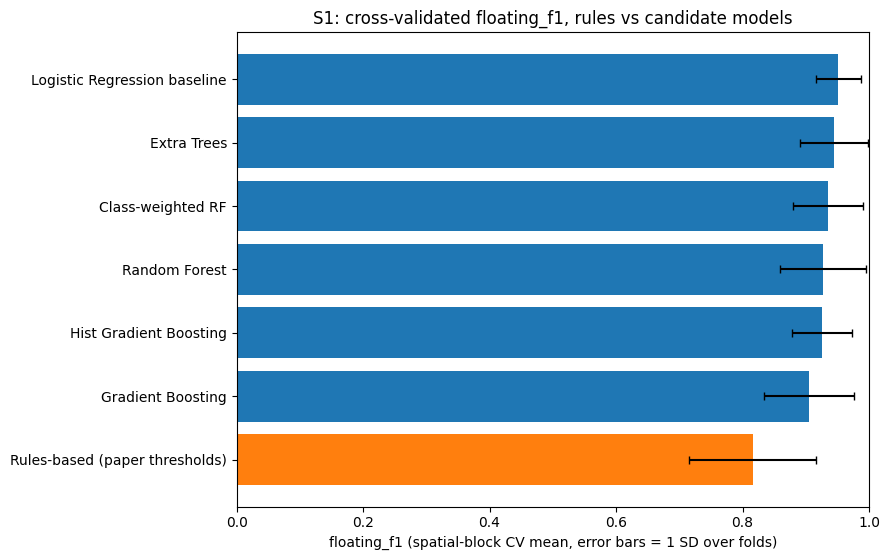

In [24]:
def plot_leaderboard_metric(sensor, metric=ACCURACY_LEADERBOARD_SORT_METRIC):
    """Rules row against every model row on one cross-validated metric."""
    d = leaderboard_df[leaderboard_df["sensor_key"].eq(sensor)].copy()
    if d.empty:
        return None

    mean_col, std_col = f"{metric}_mean", f"{metric}_std"
    d = d.dropna(subset=[mean_col]).sort_values(mean_col)
    if d.empty:
        return None

    colours = [
        "tab:orange" if name == RULES_MODEL_NAME else "tab:blue"
        for name in d["model"]
    ]

    fig, ax = plt.subplots(figsize=(9.0, 0.5 * len(d) + 2.2))

    ax.barh(
        d["model"],
        d[mean_col],
        xerr=d[std_col].fillna(0.0),
        color=colours,
        capsize=3,
    )

    ax.set_xlabel(f"{metric} (spatial-block CV mean, error bars = 1 SD over folds)")
    ax.set_xlim(0, 1)
    ax.set_title(f"{sensor}: cross-validated {metric}, rules vs candidate models")

    fig.tight_layout()

    out = FIGURE_DIR / f"{sensor.lower()}_rules_vs_models_{metric}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


if not leaderboard_df.empty:
    for sensor in SENSOR_FILTER:
        plot_leaderboard_metric(sensor)

### 13e. Confusion matrices

Rows are the labelled reference class; columns are the class the rules assigned. Cell
text gives the point count and the percentage of that reference row, so the diagonal
reads as producer's accuracy.

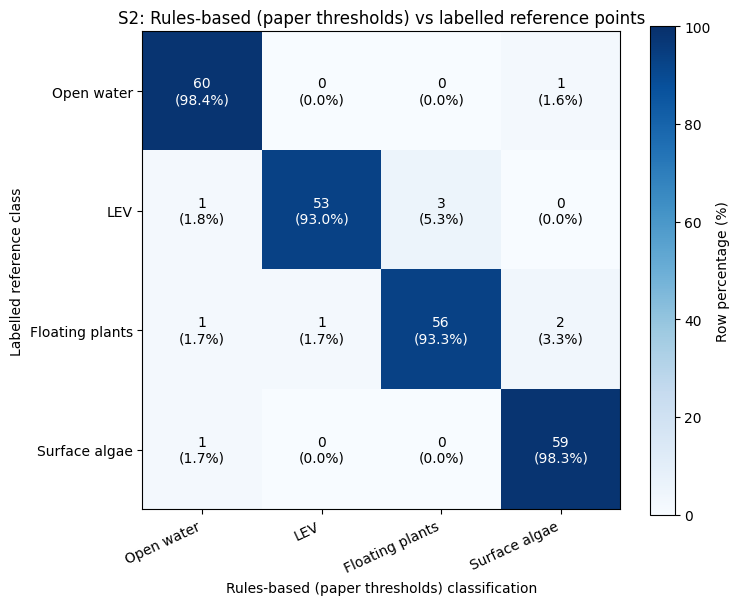

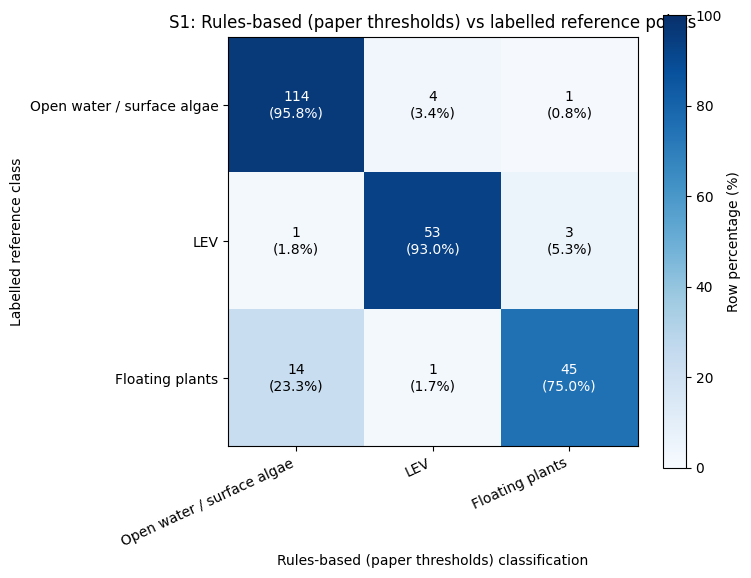

In [25]:
def plot_confusion_matrix(sensor, matrix, classifier, filename_stem, title=None):
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    row_totals = matrix.sum(axis=1, keepdims=True)

    row_pct = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype=float),
        where=row_totals != 0,
    ) * 100.0

    fig, ax = plt.subplots(figsize=(7.6, 6.2))
    im = ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=100)

    labels = [class_labels[c] for c in class_codes]

    ax.set_xticks(range(len(labels)), labels=labels, rotation=25, ha="right")
    ax.set_yticks(range(len(labels)), labels=labels)

    ax.set_xlabel(f"{classifier} classification")
    ax.set_ylabel("Labelled reference class")
    ax.set_title(title or f"{sensor}: {classifier} vs labelled reference points")

    for i in range(len(class_codes)):
        for j in range(len(class_codes)):
            text_color = "white" if row_pct[i, j] > 50 else "black"
            ax.text(
                j,
                i,
                f"{int(matrix[i, j]):,}\n({row_pct[i, j]:.1f}%)",
                ha="center",
                va="center",
                color=text_color,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row percentage (%)")

    fig.tight_layout()

    out = FIGURE_DIR / f"{sensor.lower()}_{filename_stem}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor, matrix in rules_confusion_matrices.items():
    plot_confusion_matrix(
        sensor,
        matrix,
        classifier=RULES_MODEL_NAME,
        filename_stem="rules_accuracy_confusion_matrix",
    )

### 13f. Map-space accuracy: both classifiers at the reference points

The routes above score the rule *thresholds*. This one scores the rule *maps*: each
reference point is matched to the paired scene whose period contains its acquisition
date, and both the rules-based and the Logistic Regression raster are sampled there.
Points where either raster is NoData — outside the AOI, off the water mask, or
outside the predictor-valid area — are dropped, so both classifiers are scored on
exactly the same points.

> Logistic Regression was trained on these points, so its map-space score is
> optimistic in a way the rules-based score is not. Quote 13d for a like-for-like
> comparison and 13f for the accuracy of the delivered maps.

In [26]:
def sample_raster_at_points(tif_path, lons, lats, nodata_value=NODATA_VALUE):
    """Nearest-pixel raster values at lon/lat points, NoData where outside the grid."""
    lons = np.asarray(lons, dtype=np.float64)
    lats = np.asarray(lats, dtype=np.float64)
    values = np.full(lons.shape, nodata_value, dtype=np.int64)

    local = staged_copy(tif_path)

    with rasterio.open(local) as src:
        if src.crs is None:
            xs, ys = lons, lats
        else:
            transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
            xs, ys = transformer.transform(lons, lats)

        for i, (x, y) in enumerate(zip(np.atleast_1d(xs), np.atleast_1d(ys))):
            if not (np.isfinite(x) and np.isfinite(y)):
                continue
            row, col = src.index(x, y)
            if not (0 <= row < src.height and 0 <= col < src.width):
                continue
            window = Window(col_off=int(col), row_off=int(row), width=1, height=1)
            values[i] = int(src.read(1, window=window)[0, 0])

    return values


def match_reference_points_to_scenes(points, manifest,
                                     tolerance_days=MAP_MATCH_TOLERANCE_DAYS):
    """Attach each reference point to the paired scene covering its acquisition date.

    A scene is a candidate when the point date falls inside its period, widened by
    ``tolerance_days``. When several periods qualify, the one whose midpoint is
    closest to the point date wins, so no point is scored twice.
    """
    tolerance = pd.Timedelta(days=int(tolerance_days))

    points = points.copy()
    points["acquired"] = pd.to_datetime(points["date"], errors="coerce")

    rows = []
    for sensor, sensor_points in points.groupby("sensor", sort=False):
        scenes = manifest[manifest["sensor"].eq(sensor)]
        if scenes.empty:
            print(f"{sensor}: no paired scenes to sample.")
            continue

        midpoints = (
            scenes["start_date"]
            + (scenes["end_date"] - scenes["start_date"]) / 2
        )

        for idx, point in sensor_points.iterrows():
            when = point["acquired"]
            if pd.isna(when):
                continue

            covers = (
                (scenes["start_date"] - tolerance <= when)
                & (when <= scenes["end_date"] + tolerance)
            )
            if not covers.any():
                continue

            offsets = (midpoints[covers] - when).abs()
            best = scenes.loc[offsets.idxmin()]

            rows.append({
                "reference_index": idx,
                "sensor": sensor,
                "prefix": best["prefix"],
                "scene_start_date": best["start_date"],
                "scene_end_date": best["end_date"],
                "n_candidate_scenes": int(covers.sum()),
                "model_tif": best["model_tif"],
                "rule_tif": best["rule_tif"],
                "acquired": when,
                "lon": point["lon"],
                "lat": point["lat"],
                "reference_code": point["reference_code"],
                "reference_class": point["reference_class"],
                "spatial_block": point["spatial_block"],
            })

    return pd.DataFrame(rows)


def sample_maps_at_reference_points(matched):
    """Sample the rules and Logistic Regression rasters at the matched points."""
    blocks = []
    for (sensor, prefix), group in matched.groupby(["sensor", "prefix"], sort=True):
        block = group.copy()
        block["rule_map_code"] = sample_raster_at_points(
            group["rule_tif"].iloc[0], group["lon"], group["lat"]
        )
        block["lr_map_code"] = sample_raster_at_points(
            group["model_tif"].iloc[0], group["lon"], group["lat"]
        )

        valid_codes = class_codes_for(sensor)
        block["common_valid"] = (
            block["rule_map_code"].isin(valid_codes)
            & block["lr_map_code"].isin(valid_codes)
        )
        blocks.append(block)

    if not blocks:
        return pd.DataFrame()

    sampled = pd.concat(blocks, ignore_index=True)

    # Class labels are sensor-specific, so the lookup is per row, not per column.
    for column, source in [("rule_map_class", "rule_map_code"),
                           ("lr_map_class", "lr_map_code")]:
        sampled[column] = [
            SENSOR_CLASS_LABELS.get(sensor, {}).get(code)
            for sensor, code in zip(sampled["sensor"], sampled[source])
        ]
    return sampled

In [27]:
map_accuracy_rows = []
map_per_class_rows = []
map_confusion_rows = []
map_confusion_matrices = {}
map_sampled_points = pd.DataFrame()

EVALUATION_MAP_SPACE = "reference points (map space)"

MAP_PREDICTION_COLUMNS = {
    RULES_MODEL_NAME: "rule_map_code",
    LR_MODEL_NAME: "lr_map_code",
}

if ACCURACY_AVAILABLE and SAMPLE_MAPS_AT_REFERENCE_POINTS:
    matched_points = match_reference_points_to_scenes(reference_points, paired)

    if matched_points.empty:
        print(
            "No reference point falls inside a paired scene period. Widen "
            "MAP_MATCH_TOLERANCE_DAYS, or classify the scenes covering the "
            "reference acquisition dates, to enable the map-space route."
        )
    else:
        map_sampled_points = sample_maps_at_reference_points(matched_points)
        map_sampled_points.to_csv(
            TABLE_DIR / "rules_vs_lr_map_accuracy_points.csv", index=False)

        print("Reference points matched to paired scenes:")
        display(
            map_sampled_points.groupby("sensor")
            .agg(
                matched_points=("reference_code", "size"),
                scenes=("prefix", "nunique"),
                common_valid_points=("common_valid", "sum"),
            )
            .reset_index()
        )

        for sensor in SENSOR_FILTER:
            points = map_sampled_points[
                map_sampled_points["sensor"].eq(sensor)
                & map_sampled_points["common_valid"]
            ]

            if points.empty:
                print(f"{sensor}: no common-valid sampled points; skipping.")
                continue

            labels = list(class_codes_for(sensor))
            y_true = points["reference_code"].to_numpy()

            for classifier, column in MAP_PREDICTION_COLUMNS.items():
                y_pred = points[column].to_numpy()

                map_accuracy_rows.append({
                    "sensor": sensor,
                    "classifier": classifier,
                    "evaluation": EVALUATION_MAP_SPACE,
                    "scenes": int(points["prefix"].nunique()),
                    "spatial_blocks": int(points["spatial_block"].nunique()),
                    **classification_metrics(y_true, y_pred, labels),
                })

                map_per_class_rows.extend(
                    per_class_metrics(
                        y_true, y_pred, sensor,
                        classifier=classifier,
                        evaluation=EVALUATION_MAP_SPACE,
                    )
                )

                confusion_rows, matrix = confusion_long_form(
                    y_true, y_pred, sensor,
                    classifier=classifier,
                    evaluation=EVALUATION_MAP_SPACE,
                )
                map_confusion_rows.extend(confusion_rows)
                map_confusion_matrices[(sensor, classifier)] = matrix

map_accuracy_df = pd.DataFrame(map_accuracy_rows)
map_accuracy_per_class_df = pd.DataFrame(map_per_class_rows)
map_accuracy_confusion_df = pd.DataFrame(map_confusion_rows)

if not map_accuracy_df.empty:
    map_accuracy_df.to_csv(
        TABLE_DIR / "rules_vs_lr_map_accuracy.csv", index=False)
    map_accuracy_per_class_df.to_csv(
        TABLE_DIR / "rules_vs_lr_map_accuracy_per_class.csv", index=False)
    map_accuracy_confusion_df.to_csv(
        TABLE_DIR / "rules_vs_lr_map_accuracy_confusion_matrix.csv", index=False)

    print("\nMapped-classification accuracy at the labelled reference points:")
    display(map_accuracy_df.round(4))

    print("\nPer-class map accuracy:")
    display(map_accuracy_per_class_df.round(4))

S1: no paired scenes to sample.
Reference points matched to paired scenes:


,sensor,matched_points,scenes,common_valid_points
0,S2,200,10,150


S1: no common-valid sampled points; skipping.

Mapped-classification accuracy at the labelled reference points:


,sensor,classifier,evaluation,scenes,spatial_blocks,n_points,accuracy,balanced_accuracy,kappa,macro_f1,weighted_f1,floating_precision,floating_recall,floating_f1,floating_support
0,S2,Rules-based (paper thresholds),reference points (map space),10,23,150,0.96,0.9077,0.9421,0.9325,0.9590,0.9583,0.9388,0.9485,49
1,S2,Logistic Regression,reference points (map space),10,23,150,0.96,0.9671,0.9423,0.9683,0.9601,1.0000,0.9796,0.9897,49



Per-class map accuracy:


,sensor,classifier,evaluation,class_code,class_name,reference_points,predicted_points,precision_users_accuracy,recall_producers_accuracy,f1
0,S2,Rules-based (paper thresholds),reference points (map space),0,Open water,45,45,0.9778,0.9778,0.9778
1,S2,Rules-based (paper thresholds),reference points (map space),1,LEV,7,5,1.0000,0.7143,0.8333
2,S2,Rules-based (paper thresholds),reference points (map space),2,Floating plants,49,48,0.9583,0.9388,0.9485
3,S2,Rules-based (paper thresholds),reference points (map space),3,Surface algae,49,52,0.9423,1.0000,0.9703
4,S2,Logistic Regression,reference points (map space),0,Open water,45,40,1.0000,0.8889,0.9412
5,S2,Logistic Regression,reference points (map space),1,LEV,7,7,1.0000,1.0000,1.0000
6,S2,Logistic Regression,reference points (map space),2,Floating plants,49,48,1.0000,0.9796,0.9897
7,S2,Logistic Regression,reference points (map space),3,Surface algae,49,55,0.8909,1.0000,0.9423


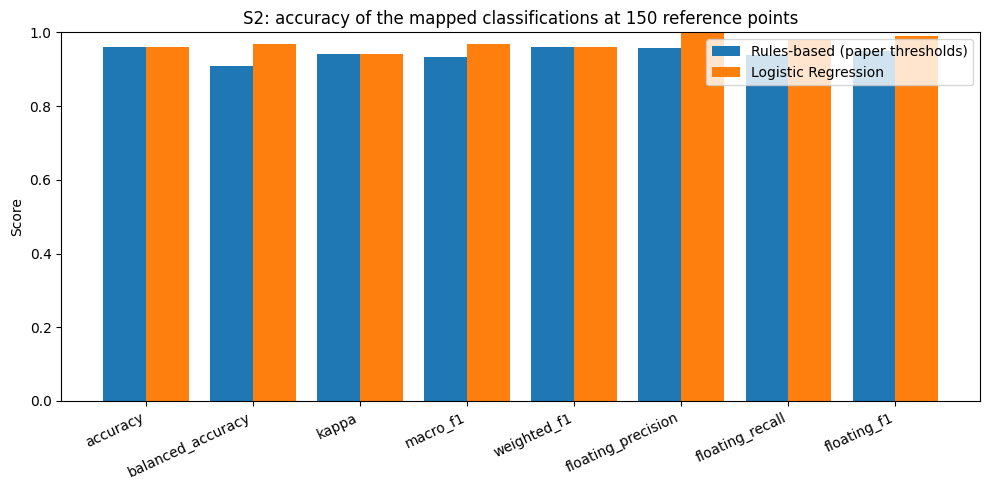

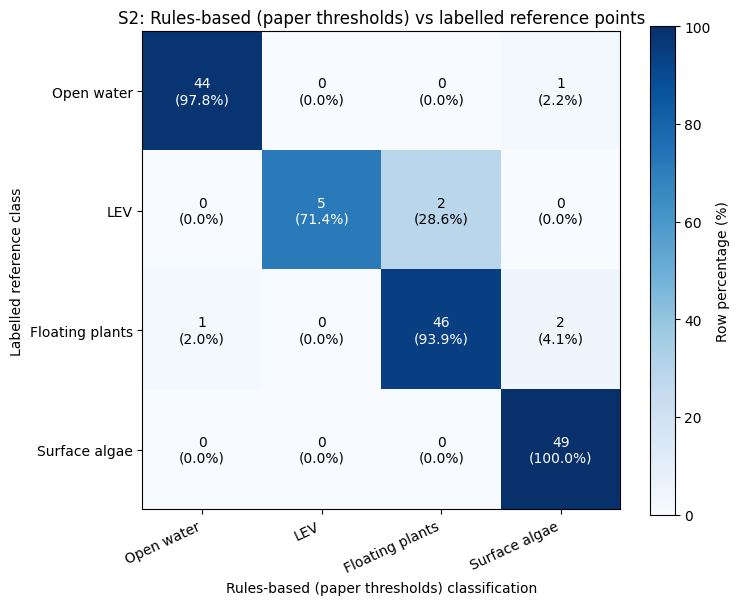

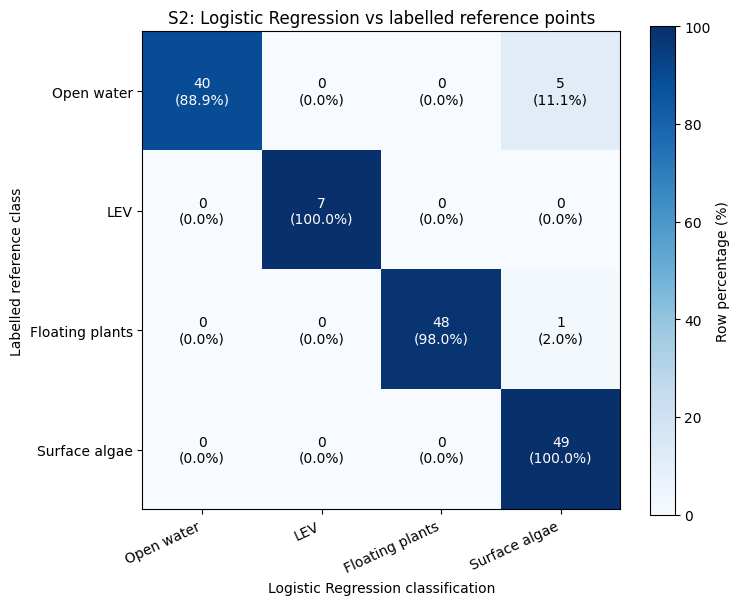

In [28]:
def plot_map_accuracy_comparison(sensor):
    """Rules vs Logistic Regression on the shared metric suite, same points."""
    d = map_accuracy_df[map_accuracy_df["sensor"].eq(sensor)]
    if d.empty:
        return None

    classifiers = list(MAP_PREDICTION_COLUMNS)
    positions = np.arange(len(ACCURACY_METRICS))
    width = 0.8 / len(classifiers)

    fig, ax = plt.subplots(figsize=(10.0, 5.0))

    for i, classifier in enumerate(classifiers):
        row = d[d["classifier"].eq(classifier)]
        if row.empty:
            continue
        values = [float(row.iloc[0][metric]) for metric in ACCURACY_METRICS]
        ax.bar(
            positions + i * width - 0.4 + width / 2,
            values,
            width=width,
            label=classifier,
        )

    ax.set_xticks(positions, labels=ACCURACY_METRICS, rotation=25, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(
        f"{sensor}: accuracy of the mapped classifications at "
        f"{int(d['n_points'].iloc[0]):,} reference points"
    )
    ax.legend()

    fig.tight_layout()

    out = FIGURE_DIR / f"{sensor.lower()}_rules_vs_lr_map_accuracy.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


if not map_accuracy_df.empty:
    for sensor in SENSOR_FILTER:
        plot_map_accuracy_comparison(sensor)

    for (sensor, classifier), matrix in map_confusion_matrices.items():
        stem = (
            "rules" if classifier == RULES_MODEL_NAME else "lr"
        ) + "_map_accuracy_confusion_matrix"
        plot_confusion_matrix(sensor, matrix, classifier=classifier, filename_stem=stem)

### 13g. Reporting these numbers

- **Rules-based accuracy on the original reference points** — quote section 13c
  (pooled) or 13d (`{metric}_mean` ± `{metric}_std` over spatial folds). 13d can sit
  beside the model rows in a candidate-comparison table because the folds are built the
  same way, but carry the caveat there that the reference datasets differ.
- **Which classifier is more accurate** — use section **13h**, the paired S2
  fixed-validation comparison: identical held-out points, identical reference labels,
  and Logistic Regression predictions that are genuinely held out. 13d scores the two
  on different reference datasets, and the map-space table in 13f answers a different
  question again (how accurate are the delivered rasters), favouring Logistic
  Regression because it was fitted on those points.
- **Class-specific claims** — `floating_precision` / `floating_recall` in the pooled
  and per-class tables are the user's and producer's accuracy for floating plants,
  which is the class the area time series depends on.
- **Caveats to carry into the text** — a single labelled set serving as both training
  and reference data; reference points concentrated on a handful of acquisition
  dates; and, for S1 in predictor space, CSV backscatter rather than the SCC
  re-sampled values the deployed model uses.

Accuracy reported here does not replace the concordance analysis above: sections 4–12
cover the whole classified stack, whereas this section covers only the pixels that
carry a label.

### 13h. S2 fixed-validation comparison: rules versus expanded-data Logistic Regression

**This is the primary like-for-like accuracy comparison between the paper thresholds
and the fitted classifier**, and it is the section to quote when asking whether the
machine-learning classifier beats the rules.

Both classifiers are scored on **exactly the same fixed validation points**: the
held-out spatial blocks that `run_s2_fixed_validation_diagnostic()` in
`Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb` sets aside from the expanded
manual-corrections dataset. That function owns the split — `_s2_diag_ready_df()`,
`_spatial_validation_row_ids()`, `S2_DIAGNOSTIC_VALIDATION_FRACTION` and
`S2_DIAGNOSTIC_RANDOM_STATE` — and this notebook reproduces no part of it. It reads the
manifest that function exports and replays the thresholds on those same rows.

What makes the comparison genuinely paired:

- identical validation point ids (`_s2_diag_row_id`), in one shared order;
- identical reference labels (`true_class`), read from the manifest rather than
  re-derived;
- identical point count, spatial blocks, class support and original/manual-correction
  composition — verified from the scored rows, not assumed;
- Logistic Regression predictions taken from the manifest's
  `corrected_full_excluding_validation` arm, so **the model was fitted only on the
  complementary training rows** and these are genuine held-out predictions;
- rule predictions from the section 13a `s2_rule_class_at_points()` implementation,
  thresholds and branch order untouched;
- the same `classification_metrics()`, `per_class_metrics()` and
  `confusion_long_form()` definitions applied to both classifiers.

#### Why this evaluation set is deliberately demanding

- The **rules contain no fitted parameters at all**. They never saw the training rows,
  so nothing about this split can advantage or disadvantage them.
- The fixed validation set contains **both original reference observations and
  manually corrected ones**. The correction points were targeted at difficult or
  previously misclassified locations, so the evaluation set is harder than the original
  points alone — the classifier notebook's own point-difficulty diagnostic measures
  exactly that gap.
- Because both classifiers meet the same hard points, neither is flattered, and the
  paired difference between them is the robust part of the result.

#### What this section does not do

It does not retrain Logistic Regression, and it does not sample the production LR
raster. If either classifier turns out to be unevaluable at a point, the cells below
raise rather than dropping the point: dropping it would silently end the pairing.

This comparison is **S2 only**. There is no equivalent expanded fixed-validation
dataset for S1 — the manual-correction rows the split is drawn from carry sampled S2
predictors, while the S1 branch re-samples its predictors from Earth Engine — so no S1
fixed-validation manifest exists and none should be implied.

In [29]:
# ---------------------------------------------------------------------
# Section 13h configuration: the S2 fixed validation set
#
# Every artifact named here is written by run_s2_fixed_validation_diagnostic()
# in Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb. That function owns the
# split, and this notebook does not reproduce any part of it: it builds the ready
# frame with _s2_diag_ready_df(), chooses the held-out spatial blocks with
# _spatial_validation_row_ids() under S2_DIAGNOSTIC_VALIDATION_FRACTION and
# S2_DIAGNOSTIC_RANDOM_STATE, fits the corrected_full_excluding_validation
# Logistic Regression arm on the complementary training rows only, and scores it
# on the held-out rows.
#
# Nothing below re-derives, re-splits, reshuffles or re-seeds that split, and no
# model is refitted here. The manifest is the source of truth; this section reads
# it and replays the paper thresholds on the same rows, in the same order.
# ---------------------------------------------------------------------
S2_FIXED_VALIDATION_SENSOR = "S2"

CLASSIFIER_DIAGNOSTIC_DIR = CLASSIFIER_ROOT / "outputs"

# One row per held-out point: ids, labels, the corrected LR predictions, the S2
# rule predictors and point provenance.
S2_FIXED_VALIDATION_MANIFEST_PATH = (
    CLASSIFIER_DIAGNOSTIC_DIR
    / "winam_s2_fixed_validation_manifest_diagnostic_more_training_data_check.csv"
)

# The classifier notebook's own metrics for the same split. Section 13h
# recomputes the Logistic Regression row and asserts it reproduces this file.
S2_FIXED_VALIDATION_METRICS_PATH = (
    CLASSIFIER_DIAGNOSTIC_DIR
    / "winam_s2_fixed_validation_diagnostic_more_training_data_check.csv"
)

# The only Logistic Regression arm this section may score: the one fitted on the
# training rows that exclude the validation blocks. Predictions from any other
# arm would be training-set predictions (or, in section 13f's case, map-space
# ones) and are rejected rather than quietly scored.
S2_FIXED_VALIDATION_LR_TRAIN_ARM = "corrected_full_excluding_validation"
S2_FIXED_VALIDATION_MODEL_NAME = "Logistic Regression baseline"

S2_FIXED_VALIDATION_ID_COLUMN = "_s2_diag_row_id"
S2_FIXED_VALIDATION_RULE_PREDICTORS = ("AWEI_p95", "AWEI", "NDMI")
S2_FIXED_VALIDATION_REQUIRED_COLUMNS = (
    "_s2_diag_row_id",
    "point_key",
    "correction_source",
    "manual_correction",
    "spatial_block",
    "true_class",
    "lr_predicted_class",
    "lr_train_arm",
    "AWEI_p95",
    "AWEI",
    "NDMI",
)

# Provenance columns copied into the per-point table when the manifest has them.
S2_FIXED_VALIDATION_PROVENANCE_COLUMNS = (
    "point_key", "scene_prefix", "lon", "lat", "date", ".geo", "dominant_class",
)

S2_FIXED_VALIDATION_EVALUATION = (
    "S2 fixed validation set (held-out spatial blocks of the expanded "
    "manual-corrections dataset)"
)
S2_FIXED_VALIDATION_LR_LABEL = "Logistic Regression — corrected training data"
S2_FIXED_VALIDATION_RULES_LABEL = "Rules-based — paper thresholds"
S2_FIXED_VALIDATION_CLASSIFIERS = (
    S2_FIXED_VALIDATION_LR_LABEL,
    S2_FIXED_VALIDATION_RULES_LABEL,
)

# Sign convention, applied to every metric without exception: positive favours
# the rules, negative favours Logistic Regression.
S2_FIXED_VALIDATION_DIFFERENCE_CONVENTION = "rules_minus_lr"

# ACCURACY_METRICS is the _score_split() suite reused from section 13b;
# floating_support and the composition counts are reported as integers beside it.
S2_FIXED_VALIDATION_METRICS = tuple(ACCURACY_METRICS) + ("floating_support",)
S2_FIXED_VALIDATION_COUNT_FIELDS = (
    "n_points",
    "n_validation_blocks",
    "n_original_points",
    "n_manual_correction_points",
)

# Tolerance for reproducing the classifier notebook's Logistic Regression row.
# The metrics come back through a CSV round-trip, so this is float noise, not a
# licence for the numbers to differ.
S2_FIXED_VALIDATION_METRIC_TOLERANCE = 1e-8

# (recomputed key, classifier-notebook column) pairs cross-checked against
# winam_s2_fixed_validation_diagnostic_more_training_data_check.csv.
S2_FIXED_VALIDATION_METRIC_CROSSCHECKS = (
    tuple((metric, metric) for metric in S2_FIXED_VALIDATION_METRICS)
    + (("n_points", "n_rows"), ("n_points", "validation_rows"))
)

# Okabe-Ito blue and vermillion: distinguishable under every common form of
# colour-vision deficiency and in greyscale print.
S2_FIXED_VALIDATION_COLOURS = {
    S2_FIXED_VALIDATION_LR_LABEL: "#0072B2",
    S2_FIXED_VALIDATION_RULES_LABEL: "#D55E00",
}

S2_FIXED_VALIDATION_METRIC_LABELS = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "kappa": "Cohen's κ",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
    "floating_precision": "Floating precision",
    "floating_recall": "Floating recall",
    "floating_f1": "Floating F1",
}

print("S2 fixed-validation manifest:", S2_FIXED_VALIDATION_MANIFEST_PATH)
print("  exists:", Path(S2_FIXED_VALIDATION_MANIFEST_PATH).exists())
print("S2 fixed-validation metrics: ", S2_FIXED_VALIDATION_METRICS_PATH)
print("  exists:", Path(S2_FIXED_VALIDATION_METRICS_PATH).exists())
print("Difference convention:", S2_FIXED_VALIDATION_DIFFERENCE_CONVENTION,
      "(positive favours the rules)")


S2 fixed-validation manifest: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_manifest_diagnostic_more_training_data_check.csv
  exists: True
S2 fixed-validation metrics:  /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s2_fixed_validation_diagnostic_more_training_data_check.csv
  exists: True
Difference convention: rules_minus_lr (positive favours the rules)


In [30]:
def validate_fixed_validation_ids(manifest, id_column=S2_FIXED_VALIDATION_ID_COLUMN):
    """Return the manifest's validation ids, or raise if they cannot be trusted.

    The id is the join key that makes this comparison paired, so it has to be
    present, complete and unique before anything is scored. A duplicated id would
    double-weight a point; a missing one would leave a point unattributable.
    """
    if id_column not in manifest.columns:
        raise ValueError(
            f"The fixed-validation manifest has no {id_column!r} column. It must be "
            "the artifact written by run_s2_fixed_validation_diagnostic() in "
            "Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb."
        )

    ids = pd.to_numeric(manifest[id_column], errors="coerce")

    incomplete = int(ids.isna().sum())
    if incomplete:
        raise ValueError(
            f"{incomplete} of {len(manifest)} fixed-validation row(s) have a missing or "
            f"non-numeric {id_column}. Re-export the manifest; it is not usable as a "
            "paired evaluation set."
        )

    duplicated = ids[ids.duplicated(keep=False)]
    if not duplicated.empty:
        repeated = sorted(int(v) for v in duplicated.unique())
        raise ValueError(
            f"{len(duplicated)} fixed-validation row(s) share {len(repeated)} duplicated "
            f"{id_column} value(s) (first few: {repeated[:10]}). Each held-out point must "
            "appear exactly once, or it is silently weighted twice in every metric."
        )

    return ids.astype(np.int64).to_numpy()


def validate_fixed_validation_rule_predictors(
    manifest, predictors=S2_FIXED_VALIDATION_RULE_PREDICTORS
):
    """Return the rule predictors as floats, or raise if any point is unevaluable.

    Dropping the offending rows instead would leave the two classifiers scored on
    different point sets, which is precisely the failure this section exists to
    rule out. A manifest with a non-finite predictor is an export problem, not a
    row to quietly delete.
    """
    missing = [column for column in predictors if column not in manifest.columns]
    if missing:
        raise ValueError(
            f"The fixed-validation manifest is missing the S2 rule predictor(s) {missing}. "
            "Re-run the '8d. S2 more-training-data diagnostics' cell in the classifier "
            "notebook, which writes them into the manifest."
        )

    values = manifest[list(predictors)].apply(pd.to_numeric, errors="coerce")
    finite = np.isfinite(values.to_numpy(dtype=np.float64))
    unevaluable = ~finite.all(axis=1)

    if unevaluable.any():
        ids = manifest.loc[unevaluable, S2_FIXED_VALIDATION_ID_COLUMN].tolist()
        raise ValueError(
            f"{int(unevaluable.sum())} of {len(manifest)} fixed-validation point(s) have a "
            f"non-finite S2 rule predictor (ids: {ids[:10]}). The rules cannot classify "
            "them, so the two classifiers could only be compared by deleting points from "
            "one side. Fix the export rather than the point set."
        )

    return values.astype(np.float64)


def load_s2_fixed_validation_manifest(
    path=S2_FIXED_VALIDATION_MANIFEST_PATH,
    train_arm=S2_FIXED_VALIDATION_LR_TRAIN_ARM,
    sensor=S2_FIXED_VALIDATION_SENSOR,
):
    """Load and fully validate the classifier notebook's fixed-validation manifest.

    Returns the manifest sorted by validation id, so every downstream vector is in
    one deterministic order shared by both classifiers.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"S2 fixed-validation manifest not found: {path}. Re-run the "
            "'8d. S2 more-training-data diagnostics' cell in "
            "Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb to write it."
        )

    manifest = pd.read_csv(path)

    missing = [
        column
        for column in S2_FIXED_VALIDATION_REQUIRED_COLUMNS
        if column not in manifest.columns
    ]
    if missing:
        raise ValueError(
            f"{path.name} is missing required column(s) {missing}. It does not look like "
            "the fixed-validation manifest this section expects."
        )

    validate_fixed_validation_ids(manifest)
    validate_fixed_validation_rule_predictors(manifest)

    arms = sorted(set(manifest["lr_train_arm"].astype(str)))
    if arms != [train_arm]:
        raise ValueError(
            f"{path.name} carries Logistic Regression predictions from arm(s) {arms}, but "
            f"section 13h may only score {train_arm!r} — the arm fitted on the training "
            "rows that exclude these validation blocks. Any other arm would be a "
            "training-set prediction."
        )

    valid_codes = set(class_codes_for(sensor))
    for column in ("true_class", "lr_predicted_class"):
        codes = pd.to_numeric(manifest[column], errors="coerce")
        if codes.isna().any():
            raise ValueError(
                f"{path.name} has {int(codes.isna().sum())} row(s) with a missing "
                f"{column}; the evaluation set is incomplete."
            )
        unexpected = sorted(set(codes.astype(int).tolist()) - valid_codes)
        if unexpected:
            raise ValueError(
                f"{path.name} column {column!r} contains class code(s) {unexpected} outside "
                f"the {sensor} scheme {sorted(valid_codes)}."
            )
        manifest[column] = codes.astype(np.int64)

    manifest[S2_FIXED_VALIDATION_ID_COLUMN] = manifest[
        S2_FIXED_VALIDATION_ID_COLUMN
    ].astype(np.int64)
    manifest["manual_correction"] = (
        pd.to_numeric(manifest["manual_correction"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    return manifest.sort_values(S2_FIXED_VALIDATION_ID_COLUMN).reset_index(drop=True)


def load_s2_fixed_validation_metrics_row(
    path=S2_FIXED_VALIDATION_METRICS_PATH,
    train_arm=S2_FIXED_VALIDATION_LR_TRAIN_ARM,
    model_name=S2_FIXED_VALIDATION_MODEL_NAME,
):
    """The classifier notebook's own metrics row for the corrected LR arm."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"S2 fixed-validation metrics not found: {path}. Re-run the "
            "'8d. S2 more-training-data diagnostics' cell in "
            "Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb to write it."
        )

    table = pd.read_csv(path)
    match = table[table["train_arm"].astype(str).eq(train_arm)]
    if "model" in table.columns:
        match = match[match["model"].astype(str).eq(model_name)]

    if len(match) != 1:
        raise ValueError(
            f"Expected exactly one {train_arm!r} row for {model_name!r} in {path.name}, "
            f"found {len(match)}."
        )

    return match.iloc[0]


def s2_fixed_validation_predictions(manifest):
    """Both classifiers' predictions for the manifest's rows, in manifest order.

    Logistic Regression is read straight out of the manifest: these are the
    held-out predictions the classifier notebook made with the
    corrected_full_excluding_validation arm. No model is refitted here and no
    raster is sampled, so nothing in this section can pick up a training-set or a
    map-space prediction by accident.

    The rules come from s2_rule_class_at_points() exactly as defined in section
    13a — same thresholds, same branch order, no re-tuning.
    """
    rule_code = s2_rule_class_at_points(manifest)

    unevaluable = np.flatnonzero(np.asarray(rule_code) == NODATA_VALUE)
    if unevaluable.size:
        ids = manifest[S2_FIXED_VALIDATION_ID_COLUMN].to_numpy()[unevaluable]
        raise ValueError(
            f"The paper thresholds could not classify {unevaluable.size} fixed-validation "
            f"point(s) (ids: {ids[:10].tolist()}). Scoring the remainder would compare the "
            "two classifiers on different point sets."
        )

    return {
        S2_FIXED_VALIDATION_LR_LABEL: manifest["lr_predicted_class"].to_numpy(np.int64),
        S2_FIXED_VALIDATION_RULES_LABEL: np.asarray(rule_code).astype(np.int64),
    }


def s2_fixed_validation_points_long_form(
    manifest, predictions, sensor=S2_FIXED_VALIDATION_SENSOR
):
    """One row per (validation point, classifier), in manifest order."""
    class_labels = class_labels_for(sensor)
    carried = [
        column
        for column in (
            S2_FIXED_VALIDATION_ID_COLUMN,
            "correction_source",
            "manual_correction",
            "spatial_block",
            "true_class",
        )
        + S2_FIXED_VALIDATION_PROVENANCE_COLUMNS
        if column in manifest.columns
    ]

    frames = []
    for classifier, y_pred in predictions.items():
        block = manifest[carried].copy()
        block.insert(0, "classifier", classifier)
        block.insert(0, "evaluation", S2_FIXED_VALIDATION_EVALUATION)
        block.insert(0, "sensor", sensor)
        block["predicted_class"] = np.asarray(y_pred, dtype=np.int64)
        block["true_class_name"] = block["true_class"].map(class_labels)
        block["predicted_class_name"] = block["predicted_class"].map(class_labels)
        block["correct"] = block["predicted_class"].eq(block["true_class"])
        frames.append(block)

    return pd.concat(frames, ignore_index=True)


def s2_fixed_validation_fingerprint(
    points, classifier, id_column=S2_FIXED_VALIDATION_ID_COLUMN
):
    """Everything about one classifier's evaluated point set that must be shared.

    Derived from the rows actually scored, not from how they were assembled, so a
    future change that filtered one classifier's points is caught rather than
    assumed away.
    """
    scored = points[points["classifier"].eq(classifier)]
    ids = scored[id_column].to_numpy(np.int64)

    return {
        "classifier": classifier,
        "point_ids": tuple(int(v) for v in ids),
        "n_points": int(ids.size),
        "class_support": tuple(
            sorted((int(k), int(v)) for k, v in scored["true_class"].value_counts().items())
        ),
        "spatial_blocks": tuple(sorted(int(v) for v in set(scored["spatial_block"]))),
        "composition": tuple(
            sorted(
                (str(k), int(v))
                for k, v in scored["correction_source"].astype(str).value_counts().items()
            )
        ),
    }


def _fingerprint_mismatch_detail(field, left, right):
    """A readable description of one fingerprint disagreement."""
    if field == "point_ids":
        left_only = sorted(set(left) - set(right))
        right_only = sorted(set(right) - set(left))
        if left_only or right_only:
            return (
                f"{len(left_only)} id(s) scored only by the first classifier "
                f"({left_only[:10]}) and {len(right_only)} only by the second "
                f"({right_only[:10]})"
            )
        return "the same ids in a different order"
    return f"{left} vs {right}"


def assert_s2_fixed_validation_is_paired(
    points, classifiers=S2_FIXED_VALIDATION_CLASSIFIERS
):
    """Fail unless every classifier was scored on exactly the same evaluation set.

    Checks the point ids and their order, the point count, the reference class
    support, the spatial blocks and the original/manual-correction composition.
    """
    fingerprints = [s2_fixed_validation_fingerprint(points, c) for c in classifiers]
    reference = fingerprints[0]

    for other in fingerprints[1:]:
        for field in ("point_ids", "n_points", "class_support", "spatial_blocks",
                      "composition"):
            if reference[field] != other[field]:
                raise ValueError(
                    f"{reference['classifier']!r} and {other['classifier']!r} were not "
                    f"scored on the same {field}: "
                    f"{_fingerprint_mismatch_detail(field, reference[field], other[field])}. "
                    "This is not a paired comparison."
                )

    return reference


def s2_fixed_validation_summary(
    manifest, predictions, sensor=S2_FIXED_VALIDATION_SENSOR
):
    """Summary, per-class and confusion tables for both classifiers, same rows."""
    labels = list(class_codes_for(sensor))
    y_true = manifest["true_class"].to_numpy(np.int64)

    n_blocks = int(manifest["spatial_block"].nunique())
    n_manual = int((manifest["manual_correction"] == 1).sum())
    n_original = int((manifest["manual_correction"] == 0).sum())

    summary_rows, per_class_rows, confusion_rows, matrices = [], [], [], {}

    for classifier in S2_FIXED_VALIDATION_CLASSIFIERS:
        y_pred = predictions[classifier]
        is_lr = classifier == S2_FIXED_VALIDATION_LR_LABEL

        summary_rows.append({
            "sensor": sensor,
            "classifier": classifier,
            # The same string on both rows: it is what makes them comparable.
            "evaluation": S2_FIXED_VALIDATION_EVALUATION,
            "prediction_source": (
                f"classifier-notebook fixed-validation manifest ({S2_FIXED_VALIDATION_LR_TRAIN_ARM})"
                if is_lr
                else "paper thresholds replayed on the manifest's own predictor values"
            ),
            "fitted_parameters": "yes" if is_lr else "no",
            **classification_metrics(y_true, y_pred, labels),
            "n_validation_blocks": n_blocks,
            "n_original_points": n_original,
            "n_manual_correction_points": n_manual,
        })

        per_class_rows.extend(
            per_class_metrics(
                y_true, y_pred, sensor,
                classifier=classifier,
                evaluation=S2_FIXED_VALIDATION_EVALUATION,
            )
        )

        rows, matrix = confusion_long_form(
            y_true, y_pred, sensor,
            classifier=classifier,
            evaluation=S2_FIXED_VALIDATION_EVALUATION,
        )
        confusion_rows.extend(rows)
        matrices[classifier] = matrix

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(per_class_rows),
        pd.DataFrame(confusion_rows),
        matrices,
    )


def assert_lr_metrics_match_classifier_notebook(
    summary,
    reference_row,
    crosschecks=S2_FIXED_VALIDATION_METRIC_CROSSCHECKS,
    tolerance=S2_FIXED_VALIDATION_METRIC_TOLERANCE,
):
    """Fail unless the recomputed LR metrics reproduce the classifier notebook's row.

    This is the check that makes the comparison trustworthy: if these numbers match,
    the manifest's predictions are the very predictions the fixed-validation
    diagnostic scored, on the very points it held out.
    """
    row = summary[summary["classifier"].eq(S2_FIXED_VALIDATION_LR_LABEL)]
    if len(row) != 1:
        raise ValueError(
            f"Expected exactly one {S2_FIXED_VALIDATION_LR_LABEL!r} summary row, "
            f"found {len(row)}."
        )
    row = row.iloc[0]

    mismatches = []
    for ours, theirs in crosschecks:
        if theirs not in reference_row.index:
            mismatches.append(f"{ours}: {theirs!r} is absent from the metrics CSV")
            continue
        got = float(row[ours])
        expected = float(reference_row[theirs])
        if not np.isclose(got, expected, rtol=0.0, atol=tolerance):
            mismatches.append(
                f"{ours}: recomputed {got!r} vs classifier notebook {theirs}={expected!r}"
            )

    if mismatches:
        raise ValueError(
            "The recomputed Logistic Regression metrics do not reproduce the "
            f"{S2_FIXED_VALIDATION_LR_TRAIN_ARM!r} row of "
            f"{Path(S2_FIXED_VALIDATION_METRICS_PATH).name}: "
            + "; ".join(mismatches)
            + ". The manifest and the metrics file describe different evaluations."
        )

    return True


def s2_fixed_validation_metric_differences(
    summary,
    metrics=S2_FIXED_VALIDATION_METRICS + S2_FIXED_VALIDATION_COUNT_FIELDS,
    convention=S2_FIXED_VALIDATION_DIFFERENCE_CONVENTION,
):
    """One row per metric, differenced the same way every time: rules minus LR.

    The count fields are included deliberately: on a paired evaluation they must
    difference to exactly zero, which is a readable proof that both classifiers saw
    the same points.
    """
    lr = summary[summary["classifier"].eq(S2_FIXED_VALIDATION_LR_LABEL)].iloc[0]
    rules = summary[summary["classifier"].eq(S2_FIXED_VALIDATION_RULES_LABEL)].iloc[0]

    rows = []
    for metric in metrics:
        lr_value = float(lr[metric])
        rules_value = float(rules[metric])
        difference = rules_value - lr_value
        rows.append({
            "sensor": lr["sensor"],
            "evaluation": S2_FIXED_VALIDATION_EVALUATION,
            "metric": metric,
            "lr_value": lr_value,
            "rules_value": rules_value,
            "difference_convention": convention,
            "difference": difference,
            "favours": (
                "rules" if difference > 0 else "logistic_regression" if difference < 0 else "tie"
            ),
        })

    return pd.DataFrame(rows)


In [31]:
S2_FIXED_VALIDATION_AVAILABLE = False
s2_fixed_validation_manifest = pd.DataFrame()
s2_fixed_validation_metrics_row = None
s2_fixed_validation_points_df = pd.DataFrame()
s2_fixed_validation_accuracy_df = pd.DataFrame()
s2_fixed_validation_differences_df = pd.DataFrame()
s2_fixed_validation_per_class_df = pd.DataFrame()
s2_fixed_validation_confusion_df = pd.DataFrame()
s2_fixed_validation_matrices = {}
s2_fixed_validation_fingerprints = {}

if not (RUN_ACCURACY_EVALUATION and S2_FIXED_VALIDATION_SENSOR in SENSOR_FILTER):
    print("Section 13h skipped: S2 is not in SENSOR_FILTER, or RUN_ACCURACY_EVALUATION is False.")
else:
    try:
        # The split, the seed, the training rows and the LR fit all belong to the
        # classifier notebook. Both artifacts come from one run of it.
        s2_fixed_validation_manifest = load_s2_fixed_validation_manifest()
        s2_fixed_validation_metrics_row = load_s2_fixed_validation_metrics_row()
    except FileNotFoundError as exc:
        print("=" * 78)
        print("SECTION 13h NOT RUN — the S2 fixed-validation artifacts are not on Drive.")
        print(exc)
        print("Re-run the '8d. S2 more-training-data diagnostics' cell in")
        print("Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb; it writes both files.")
        print("Until then this notebook has no paired fixed-validation comparison, and")
        print("sections 13c-13f must not be quoted as though they were one.")
        print("=" * 78)
    else:
        S2_FIXED_VALIDATION_AVAILABLE = True

if S2_FIXED_VALIDATION_AVAILABLE:
    # Everything below is scored on exactly these rows, in exactly this order.
    s2_fixed_validation_prediction_vectors = s2_fixed_validation_predictions(
        s2_fixed_validation_manifest
    )

    s2_fixed_validation_points_df = s2_fixed_validation_points_long_form(
        s2_fixed_validation_manifest, s2_fixed_validation_prediction_vectors
    )

    # Verify the pairing from the scored rows themselves before reporting anything.
    s2_fixed_validation_reference_fingerprint = assert_s2_fixed_validation_is_paired(
        s2_fixed_validation_points_df
    )
    s2_fixed_validation_fingerprints = {
        classifier: s2_fixed_validation_fingerprint(s2_fixed_validation_points_df, classifier)
        for classifier in S2_FIXED_VALIDATION_CLASSIFIERS
    }

    (
        s2_fixed_validation_accuracy_df,
        s2_fixed_validation_per_class_df,
        s2_fixed_validation_confusion_df,
        s2_fixed_validation_matrices,
    ) = s2_fixed_validation_summary(
        s2_fixed_validation_manifest, s2_fixed_validation_prediction_vectors
    )

    # The recomputed LR row must reproduce the classifier notebook's own result.
    assert_lr_metrics_match_classifier_notebook(
        s2_fixed_validation_accuracy_df, s2_fixed_validation_metrics_row
    )

    s2_fixed_validation_differences_df = s2_fixed_validation_metric_differences(
        s2_fixed_validation_accuracy_df
    )

    s2_fixed_validation_accuracy_df.to_csv(
        TABLE_DIR / "s2_fixed_validation_rules_vs_lr_accuracy.csv", index=False)
    s2_fixed_validation_differences_df.to_csv(
        TABLE_DIR / "s2_fixed_validation_rules_vs_lr_metric_differences.csv", index=False)
    s2_fixed_validation_per_class_df.to_csv(
        TABLE_DIR / "s2_fixed_validation_rules_vs_lr_per_class.csv", index=False)
    s2_fixed_validation_confusion_df.to_csv(
        TABLE_DIR / "s2_fixed_validation_rules_vs_lr_confusion_matrix.csv", index=False)
    s2_fixed_validation_points_df.to_csv(
        TABLE_DIR / "s2_fixed_validation_rules_vs_lr_points.csv", index=False)

    _paired = s2_fixed_validation_reference_fingerprint
    print("Paired S2 fixed-validation evaluation set (identical for both classifiers):")
    # These two lines report checks that already raised if they had failed.
    print(f"  validation ids           : {S2_FIXED_VALIDATION_ID_COLUMN} present, "
          "complete and unique")
    print("  rule predictors finite   : "
          f"{', '.join(S2_FIXED_VALIDATION_RULE_PREDICTORS)} at every point")
    print(f"  validation points        : {_paired['n_points']}")
    print(f"  spatial blocks           : {len(_paired['spatial_blocks'])}")
    print(f"  reference class support  : {dict(_paired['class_support'])}")
    print(f"  point composition        : {dict(_paired['composition'])}")
    print(f"  Logistic Regression arm  : {S2_FIXED_VALIDATION_LR_TRAIN_ARM}")
    print(f"  LR training rows / blocks: "
          f"{int(s2_fixed_validation_metrics_row['train_rows'])} / "
          f"{int(s2_fixed_validation_metrics_row['train_blocks'])} "
          "(disjoint from the validation blocks above)")
    print("  LR metrics reproduce "
          f"{Path(S2_FIXED_VALIDATION_METRICS_PATH).name} to "
          f"{S2_FIXED_VALIDATION_METRIC_TOLERANCE:g}: yes")

    print("\nS2 fixed-validation accuracy, rules vs expanded-data Logistic Regression:")
    display(
        s2_fixed_validation_accuracy_df[
            ["classifier", "evaluation", "fitted_parameters"]
            + list(S2_FIXED_VALIDATION_COUNT_FIELDS)
            + list(S2_FIXED_VALIDATION_METRICS)
        ].round(4)
    )

    print(f"\nMetric differences ({S2_FIXED_VALIDATION_DIFFERENCE_CONVENTION}; "
          "positive favours the rules):")
    display(s2_fixed_validation_differences_df.round(4))

    print("\nPer-class accuracy on the same points:")
    display(s2_fixed_validation_per_class_df.round(4))


Paired S2 fixed-validation evaluation set (identical for both classifiers):
  validation ids           : _s2_diag_row_id present, complete and unique
  rule predictors finite   : AWEI_p95, AWEI, NDMI at every point
  validation points        : 172
  spatial blocks           : 6
  reference class support  : {0: 45, 1: 23, 2: 69, 3: 35}
  point composition        : {'manual_corrected_added': 137, 'original_accepted': 35}
  Logistic Regression arm  : corrected_full_excluding_validation
  LR training rows / blocks: 498 / 19 (disjoint from the validation blocks above)
  LR metrics reproduce winam_s2_fixed_validation_diagnostic_more_training_data_check.csv to 1e-08: yes

S2 fixed-validation accuracy, rules vs expanded-data Logistic Regression:


,classifier,evaluation,fitted_parameters,n_points,n_validation_blocks,n_original_points,n_manual_correction_points,accuracy,balanced_accuracy,kappa,macro_f1,weighted_f1,floating_precision,floating_recall,floating_f1,floating_support
0,Logistic Regression — corrected training data,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),yes,172,6,35,137,0.9128,0.9021,0.8776,0.9044,0.9138,0.9848,0.9420,0.9630,69
1,Rules-based — paper thresholds,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),no,172,6,35,137,0.7151,0.6490,0.5947,0.6532,0.7077,0.7917,0.8261,0.8085,69



Metric differences (rules_minus_lr; positive favours the rules):


,sensor,evaluation,metric,lr_value,rules_value,difference_convention,difference,favours
0,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),accuracy,0.9128,0.7151,rules_minus_lr,-0.1977,logistic_regression
1,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),balanced_accuracy,0.9021,0.6490,rules_minus_lr,-0.2531,logistic_regression
2,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),kappa,0.8776,0.5947,rules_minus_lr,-0.2830,logistic_regression
3,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),macro_f1,0.9044,0.6532,rules_minus_lr,-0.2512,logistic_regression
4,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),weighted_f1,0.9138,0.7077,rules_minus_lr,-0.2060,logistic_regression
5,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),floating_precision,0.9848,0.7917,rules_minus_lr,-0.1932,logistic_regression
6,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),floating_recall,0.9420,0.8261,rules_minus_lr,-0.1159,logistic_regression
7,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),floating_f1,0.9630,0.8085,rules_minus_lr,-0.1545,logistic_regression
8,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),floating_support,69.0000,69.0000,rules_minus_lr,0.0000,tie
9,S2,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),n_points,172.0000,172.0000,rules_minus_lr,0.0000,tie



Per-class accuracy on the same points:


,sensor,classifier,evaluation,class_code,class_name,reference_points,predicted_points,precision_users_accuracy,recall_producers_accuracy,f1
0,S2,Logistic Regression — corrected training data,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),0,Open water,45,49,0.8367,0.9111,0.8723
1,S2,Logistic Regression — corrected training data,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),1,LEV,23,21,0.9524,0.8696,0.9091
2,S2,Logistic Regression — corrected training data,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),2,Floating plants,69,66,0.9848,0.9420,0.9630
3,S2,Logistic Regression — corrected training data,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),3,Surface algae,35,36,0.8611,0.8857,0.8732
4,S2,Rules-based — paper thresholds,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),0,Open water,45,54,0.6852,0.8222,0.7475
5,S2,Rules-based — paper thresholds,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),1,LEV,23,18,0.4444,0.3478,0.3902
6,S2,Rules-based — paper thresholds,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),2,Floating plants,69,72,0.7917,0.8261,0.8085
7,S2,Rules-based — paper thresholds,S2 fixed validation set (held-out spatial blocks of the expanded manual-corrections dataset),3,Surface algae,35,28,0.7500,0.6000,0.6667


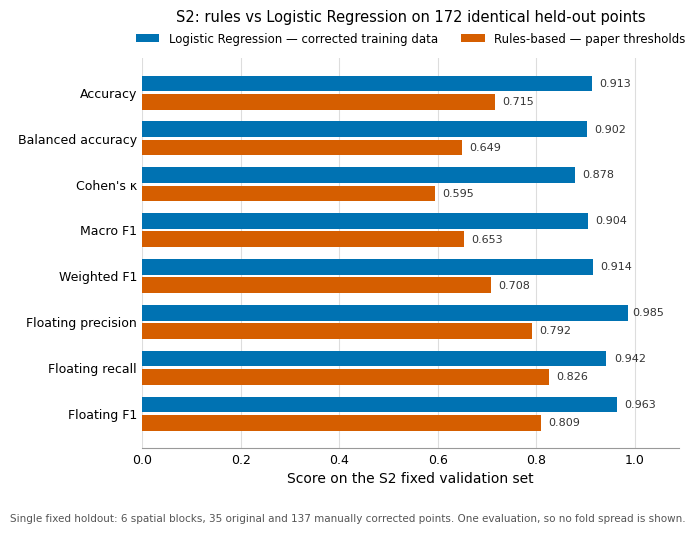

Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/figures/s2_fixed_validation_rules_vs_lr_accuracy.png


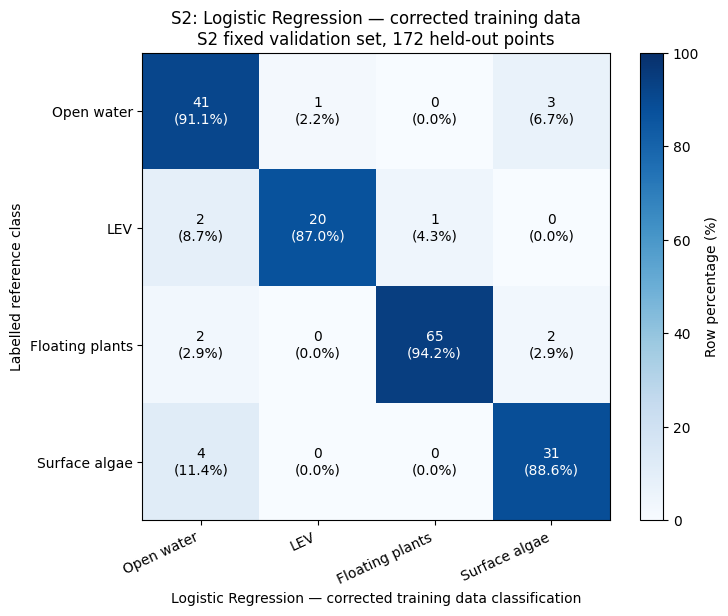

Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/figures/s2_fixed_validation_lr_confusion_matrix.png


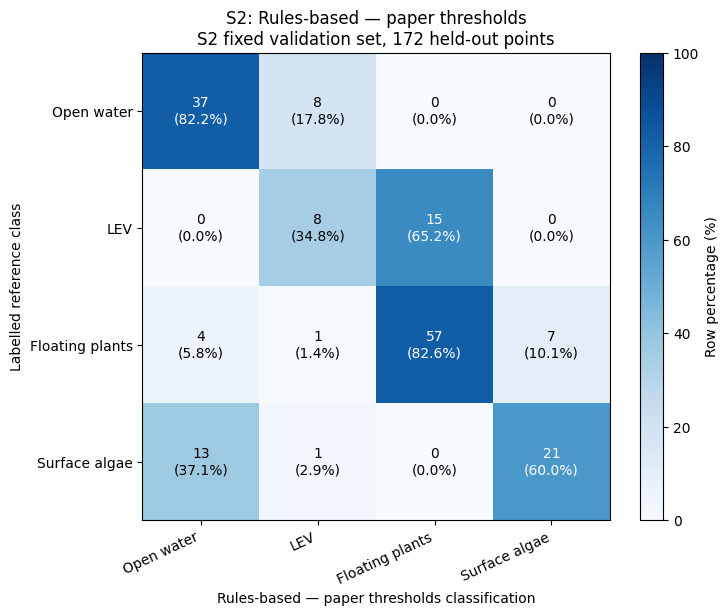

Saved: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/figures/s2_fixed_validation_rules_confusion_matrix.png


In [32]:
def plot_s2_fixed_validation_comparison(summary, metrics=ACCURACY_METRICS,
                                        sensor=S2_FIXED_VALIDATION_SENSOR):
    """Compact, light-background comparison of the two classifiers on one holdout.

    A single fixed validation set produces one number per metric per classifier,
    so the bars carry no error bars and no spread: there are no repeated folds
    here to take a standard deviation over, and drawing one would invent
    uncertainty the design does not have.
    """
    if summary.empty:
        return None

    rows = {
        classifier: summary[summary["classifier"].eq(classifier)].iloc[0]
        for classifier in S2_FIXED_VALIDATION_CLASSIFIERS
        if not summary[summary["classifier"].eq(classifier)].empty
    }
    if not rows:
        return None

    metrics = list(metrics)
    positions = np.arange(len(metrics))[::-1]  # first metric at the top
    height = 0.8 / len(rows)

    fig, ax = plt.subplots(figsize=(7.0, 0.45 * len(metrics) + 1.7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for i, (classifier, row) in enumerate(rows.items()):
        values = [float(row[metric]) for metric in metrics]
        offsets = positions + (len(rows) - 1 - i) * height - 0.4 + height / 2
        bars = ax.barh(
            offsets,
            values,
            height=height * 0.86,   # a surface gap between adjacent bars
            color=S2_FIXED_VALIDATION_COLOURS.get(classifier),
            label=classifier,
            zorder=3,
        )
        for bar, value in zip(bars, values):
            ax.text(
                min(value + 0.015, 0.995),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va="center", ha="left", fontsize=8, color="#333333", zorder=4,
            )

    reference = next(iter(rows.values()))
    ax.set_yticks(
        positions,
        labels=[S2_FIXED_VALIDATION_METRIC_LABELS.get(m, m) for m in metrics],
    )
    ax.set_xlim(0, 1.09)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_xlabel("Score on the S2 fixed validation set")
    ax.set_title(
        f"{sensor}: rules vs Logistic Regression on {int(reference['n_points']):,} "
        f"identical held-out points",
        fontsize=10.5, pad=26,
    )
    ax.tick_params(labelsize=9)

    ax.xaxis.grid(True, color="#dddddd", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#999999")
    ax.tick_params(length=0)

    # Above the plot, so it can never sit on top of a long bar.
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2,
              frameon=False, fontsize=8.5)

    fig.text(
        0.01, 0.005,
        f"Single fixed holdout: {int(reference['n_validation_blocks'])} spatial blocks, "
        f"{int(reference['n_original_points'])} original and "
        f"{int(reference['n_manual_correction_points'])} manually corrected points. "
        "One evaluation, so no fold spread is shown.",
        fontsize=7.5, color="#555555",
    )

    fig.tight_layout(rect=(0, 0.045, 1, 1))

    out = FIGURE_DIR / "s2_fixed_validation_rules_vs_lr_accuracy.png"
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

    return out


if S2_FIXED_VALIDATION_AVAILABLE:
    print("Saved:", plot_s2_fixed_validation_comparison(s2_fixed_validation_accuracy_df))

    # One dissertation-ready confusion matrix per classifier, same points, same
    # class scheme, so the two panels can sit side by side in the text.
    for _classifier, _matrix in s2_fixed_validation_matrices.items():
        _stem = (
            "fixed_validation_lr_confusion_matrix"
            if _classifier == S2_FIXED_VALIDATION_LR_LABEL
            else "fixed_validation_rules_confusion_matrix"
        )
        print("Saved:", plot_confusion_matrix(
            S2_FIXED_VALIDATION_SENSOR,
            _matrix,
            classifier=_classifier,
            filename_stem=_stem,
            title=(
                f"{S2_FIXED_VALIDATION_SENSOR}: {_classifier}\n"
                f"S2 fixed validation set, "
                f"{int(s2_fixed_validation_accuracy_df['n_points'].iloc[0]):,} held-out points"
            ),
        ))


### 13i. Reporting the paired fixed-validation comparison

- **Quote 13h for "are the rules or the model more accurate?"** It is the only place in
  this notebook where both classifiers are scored on identical points with identical
  reference labels, and where the model's predictions are genuinely held out.
- **Report it as a single fixed holdout.** One validation set, one number per metric
  per classifier. There are no folds here, so there is no fold standard deviation to
  quote, and it must not be described as cross-validation or as repeated folds.
- **Differences are `rules_minus_lr` throughout**
  (`s2_fixed_validation_rules_vs_lr_metric_differences.csv`): positive favours the
  rules, negative favours Logistic Regression, for every metric without exception. The
  count fields difference to exactly zero, which is the table's own evidence that both
  classifiers saw the same points.
- **The other analyses answer different questions and must not be substituted:**
  - 13c/13d pool the *original* `SV_S2_Training.csv` points and cross-validate the
    rules over spatial folds. They characterise the rules well, but their reference set
    is not the expanded manual-corrections dataset the corrected model is trained and
    validated on, so a 13d rules row is not directly comparable to the expanded-data
    Logistic Regression result.
  - 13f scores the delivered *rasters*, where the production Logistic Regression model
    was fitted on the very points being scored.
  - Sections 4–12 measure concordance between the two methods and say nothing about
    which one is right.
- **Carry the caveat, not a retraction.** The fixed validation set is small and
  deliberately difficult, and its manual-correction points were chosen because they
  were hard. That makes the absolute scores pessimistic relative to a random sample of
  the lake, and it is why the *paired difference* between the two classifiers — not
  either absolute number — is the claim the comparison supports.

## 14. Interpretation guardrails

Use the outputs to answer questions such as:

- How closely did the local rules and Logistic Regression classifications agree?
- Which classes were most frequently exchanged between methods?
- Did Logistic Regression systematically map more or less floating vegetation?
- Did the size of the difference vary through time or between S2 and S1?
- Where were method disagreements spatially concentrated?
- How accurate was each classifier at the labelled reference points, and which classes did each get wrong (section 13)?
- Is the fitted classifier actually more accurate than the paper thresholds on identical held-out points (section 13h)?

Do **not** describe higher agreement as higher accuracy: sections 4–12 say nothing about which classifier is right, only about how often the two coincide. The rules-based classifier is a comparator there, not a reference truth. Accuracy claims belong to section 13, which scores both classifiers against the labelled reference points and carries its own caveats.

Do **not** substitute the pooled-original-point (13c), repeated-fold (13d) or map-space (13f) analyses for the paired comparison in **13h**. Those three answer different questions, and only 13h scores the rules and the expanded-data Logistic Regression model on one identical set of held-out points. Equally, do not discard them: 13c–13f still describe the rules on the original reference set, and the accuracy of the delivered rasters, which 13h does not cover.

## 15. Output inventory

In [33]:
print("Tables")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", p)

print("\nFigures")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(" -", p)

if WRITE_DISAGREEMENT_RASTERS:
    rasters = sorted(
        DISAGREEMENT_DIR.glob("*.tif")
    )

    print("\nDisagreement GeoTIFFs")
    for p in rasters[:20]:
        print(" -", p)

    if len(rasters) > 20:
        print(
            f" ... and {len(rasters) - 20} more"
        )

if S2_FIXED_VALIDATION_AVAILABLE:
    print("\nPaired S2 fixed-validation comparison (section 13h)")
    for p in sorted(TABLE_DIR.glob("s2_fixed_validation_rules_vs_lr_*.csv")):
        print(" -", p)
    for p in sorted(FIGURE_DIR.glob("s2_fixed_validation_*.png")):
        print(" -", p)
else:
    print("\nSection 13h produced no outputs; see its cells for why.")

print("\nDone.")

Tables
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_accuracy_confusion_matrix.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_accuracy_per_class.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_accuracy_pooled.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_accuracy_reference_points.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_accuracy_spatial_cv.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_accuracy_spatial_cv_folds.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_agreement_matrix_by_scene.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_cl